In [33]:
import trompy as tp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.patches as mpatches

In [34]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp

def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltatinhours = Deltatinseconds / 3600
        pellettimes.append(Deltatinhours)

    return pellettimes

def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in dictionary.keys():
            try:
                if output_dictionary[mouse_id][key] != value:
                    output_dictionary.pop(mouse_id)
            except KeyError: 
                pass

    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list
# Function to get meal, snack, and mega meal metrics, including mega_meal_frequency and mega_meal_size
def get_meal_and_snack_metrics(pellettimes, meal_threshold=1/60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, 0, 0, 0, 0)

    IPIs = np.diff(np.array(pellettimes))
    meals = []
    snacks = []
    mega_meals = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]

    for i, ipi in enumerate(IPIs):
        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            if len(current_event) == 1:
                snacks.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:  # Make sure we are within the 7-day boundary
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 5:
                meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 6:
                mega_meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        day_index = int(current_event[0] // 24)
        hour = int(current_event[0]) % 24
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 4:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 5:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)  # Add the number of mega meals

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = max(pellettimes) - min(pellettimes)
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, meals, snacks, mega_meals, n_mega_meals)


# Function to get events (meals, snacks, mega meals) per day based on timestamps
def get_events_per_day(events, days=7):
    events_per_day = [0] * days  # Initialize with zeros for the duration of the phase
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // 24)
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        pellets = [t for t in timestamps if (t > day * 24) and (t < (day + 1) * 24)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day


# Function to calculate inter-pellet intervals (IPI)
def get_interpellet_intervals(pellettimes):
    IPIs = np.diff(pellettimes)
    return IPIs

# Function to calculate intermeal intervals (IMI)
def get_intermeal_interval(pellettimes, meal_threshold=1/60):
    IPIs = np.diff(pellettimes)
    IMIs = [x for x in IPIs if x > meal_threshold]
    average_IMI = np.mean(IMIs) if IMIs else 0  # Handle case with no IMIs
    return average_IMI

# Load the metafile and process the data
metafile = "..\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

    # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"]  # Store the number of mega meals
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"]  # Store the number of mega meals
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"]  # Store the number of mega meals
    ) = nr_metrics

    # Events per day and pellets per day (as previously done)
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)


# Now combine events and pellets per day for the entire 17-day time course (as before)
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )

# Output the results to check the data structure
for key, value in mice.items():
    print(f"Mouse {key}:")
    print("  Pellets per day:", mice[key]["all_pellets_per_day"])
    print("  Meals per day:", mice[key]["all_meals_per_day"])
    print("  Snacks per day:", mice[key]["all_snacks_per_day"])
    print("  Mega Meals per hour:", mice[key]["nr_hourly_mega_meals"])
    print("  Mega Meals Frequency:", mice[key]["nr_mega_meal_frequency"])
    print("  Mega Meals Size:", mice[key]["nr_mega_meal_size"])

Mouse FEDXA01:
  Pellets per day: [340, 271, 224, 161, 155, 176, 184, 215, 231, 240, 246, 234, 222, 211, 241, 223, 219]
  Meals per day: [47, 30, 28, 37, 33, 36, 27, 30, 34, 25, 14, 24, 24, 21, 20, 11, 11]
  Snacks per day: [30, 18, 25, 32, 44, 52, 62, 28, 25, 13, 13, 14, 14, 19, 18, 12, 13]
  Mega Meals per hour: [[0, 0, 0, 2, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 3, 2, 1, 0, 0, 1, 1, 1], [0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 0, 0, 0], [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1], [0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 2, 0, 1, 1, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 2, 3, 1, 0, 1, 0, 0, 1], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 1, 0, 2], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 2, 2, 2, 1, 1, 1, 1, 1, 2]]
  Mega Meals Frequency: 0.7914710335259267
  Mega Meals Size: 7.916666666666667
Mouse FEDXA02:
  Pellets per day: [304, 214, 194, 154, 153, 204, 211, 203, 226, 214, 

In [35]:
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"} 

6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


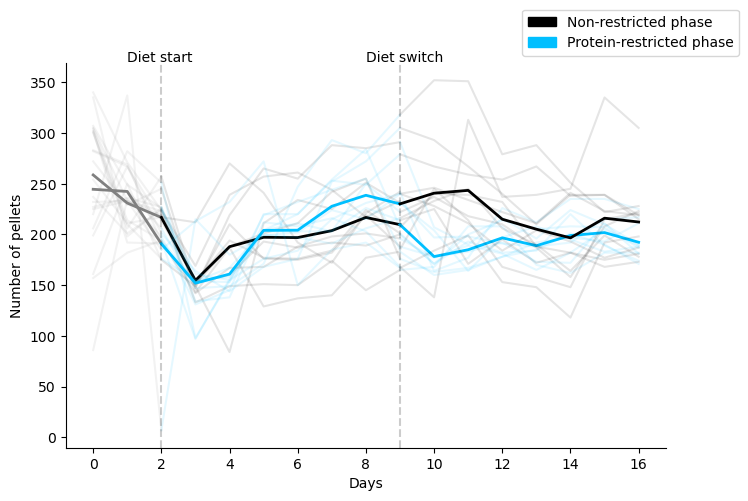

In [5]:
#plot shows timeline of total number of pellets delivered  per day in NRPR and PRNR male and Females pooled data
def timeline_fig(data, ax=[], ylabel="", **kwargs):
    if ax == []:
        f, ax = plt() #could check if ax is axis object
    
    for trace in data:
        ax.plot(trace, color="grey", alpha=0.3)
    ax.plot(np.mean(data, axis=0), linewidth=2)

    ax.set_ylabel(ylabel)
    ax.axvline(2, linestyle="--", color="k")
    ax.axvline(9, linestyle="--", color="k")

    return ax

def timeline_multicolor_fig(data, ax=[], ylabel="", colors=[], day_split=[2, 9], max_days=17, **kwargs):
    if ax == []:
        f, ax = plt.subplots() #could check if ax is axis object

    colors_reversed = colors[-1:]
    #plt.rcParams["font.size"] = 18

    for group in data:
        for trace in group:
            trace = trace[:max_days]
            ax.plot(range(0,3), trace[:3], color="grey", alpha=0.1)
            ax.plot(range(2,10), trace[2:10], color=colors[0], alpha=0.1)
            ax.plot(range(9,len(trace)), trace[9:], color=colors[1], alpha=0.1)

        mean = np.mean(group, axis=0)[:max_days]
        ax.plot(range(0,3), mean[:3], color="grey", linewidth=2)
        ax.plot(range(2,10), mean[2:10], color=colors[0], linewidth=2)
        ax.plot(range(9,len(mean)), mean[9:], color=colors[1], linewidth=2)

        colors.reverse()

    ax.set_ylabel(ylabel, fontsize= 10)
    ax.axvline(2, linestyle="--", color="k", alpha=0.2)
    ax.text(1, 370, "Diet start")
    ax.axvline(9, linestyle="--", color="k", alpha=0.2)
    ax.text(8, 370, "Diet switch")
  
 

 
   

    return ax

nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"}

nrpr_m = get_data_fields(mice, ["all_pellets_per_day"], nrpr_male_selector)
prnr_m = get_data_fields(mice, ["all_pellets_per_day"], prnr_male_selector)
nrpr_f = get_data_fields(mice, ["all_pellets_per_day"], nrpr_female_selector)
prnr_f = get_data_fields(mice, ["all_pellets_per_day"], prnr_female_selector)

f, ax = plt.subplots(nrows=1, figsize=(8,5), gridspec_kw= {"left": 0.15})



pooled_data_ctl = np.concatenate((nrpr_m, nrpr_f))
pooled_data_exp = np.concatenate((prnr_m, prnr_f))
timeline_multicolor_fig([pooled_data_ctl,pooled_data_exp], colors=["black", "deepskyblue"], ylabel="Number of pellets",ax=ax)




ax.set_xlabel("Days", fontsize = 10)
#ax.set_title("Dynamics of pellet intake", fontsize = 12, loc= "left")
#ax[0].set_title("Male", fontsize = 10, loc= "right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)  



#legends
fed_cols = ["black", "deepskyblue"]
NR_patch = mpatches.Patch(color=fed_cols[0], label='Non-restricted phase')
PR_patch = mpatches.Patch(color=fed_cols[1], label='Protein-restricted phase')
ax.legend(handles=[NR_patch, PR_patch],
             bbox_to_anchor=(1,1),
             bbox_transform=f.transFigure)

# # fig_folder= r"C:\Users\hta031\OneDrive - UiT Office 365\Documents\People\Hamid\Presentations\2024\03_MAR_2024\food_for_thought_march14\figs\\"
# #f.savefig(fig_folder + "pellet_intake_timeline_diet_label.png", dpi=300, bbox_inches="tight")
# f.savefig(fig_folder + "pellet_intake_timeline.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


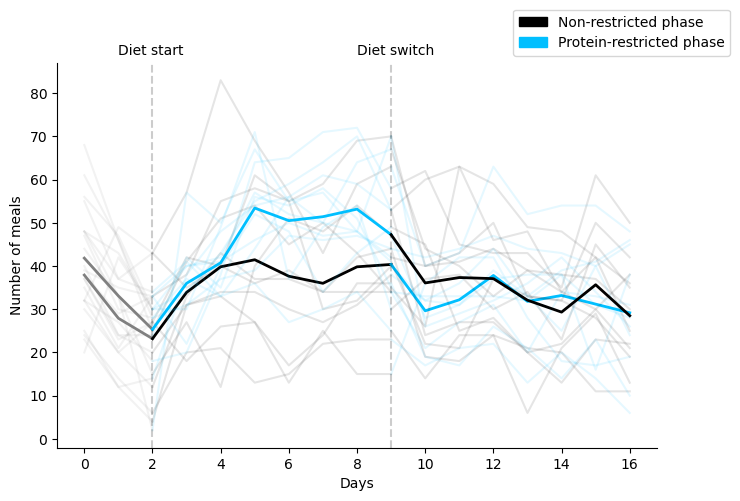

: 

In [ ]:
#plot shows timeline of total number of pellets delivered  per day in NRPR and PRNR male and Females pooled data
def timeline_fig(data, ax=[], ylabel="", **kwargs):
    if ax == []:
        f, ax = plt() #could check if ax is axis object
    
    for trace in data:
        ax.plot(trace, color="grey", alpha=0.3)
    ax.plot(np.mean(data, axis=0), linewidth=2)

    ax.set_ylabel(ylabel)
    ax.axvline(2, linestyle="--", color="k")
    ax.axvline(9, linestyle="--", color="k")

    return ax

def timeline_multicolor_fig(data, ax=[], ylabel="", colors=[], day_split=[2, 9], max_days=17, **kwargs):
    if ax == []:
        f, ax = plt.subplots() #could check if ax is axis object

    colors_reversed = colors[-1:]
    #plt.rcParams["font.size"] = 18

    for group in data:
        for trace in group:
            trace = trace[:max_days]
            ax.plot(range(0,3), trace[:3], color="grey", alpha=0.1)
            ax.plot(range(2,10), trace[2:10], color=colors[0], alpha=0.1)
            ax.plot(range(9,len(trace)), trace[9:], color=colors[1], alpha=0.1)

        mean = np.mean(group, axis=0)[:max_days]
        ax.plot(range(0,3), mean[:3], color="grey", linewidth=2)
        ax.plot(range(2,10), mean[2:10], color=colors[0], linewidth=2)
        ax.plot(range(9,len(mean)), mean[9:], color=colors[1], linewidth=2)

        colors.reverse()

    ax.set_ylabel(ylabel, fontsize= 10)
    ax.axvline(2, linestyle="--", color="k", alpha=0.2)
    ax.text(1, 89, "Diet start")
    ax.axvline(9, linestyle="--", color="k", alpha=0.2)
    ax.text(8, 89, "Diet switch")
   
    return ax

nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"}

nrpr_m = get_data_fields(mice, ["all_meals_per_day"], nrpr_male_selector)
prnr_m = get_data_fields(mice, ["all_meals_per_day"], prnr_male_selector)
nrpr_f = get_data_fields(mice, ["all_meals_per_day"], nrpr_female_selector)
prnr_f = get_data_fields(mice, ["all_meals_per_day"], prnr_female_selector)

f, ax = plt.subplots(nrows=1, figsize=(8,5), gridspec_kw= {"left": 0.15})



pooled_data_ctl = np.concatenate((nrpr_m, nrpr_f))
pooled_data_exp = np.concatenate((prnr_m, prnr_f))
timeline_multicolor_fig([pooled_data_ctl,pooled_data_exp], colors=["black", "deepskyblue"], ylabel="Number of meals",ax=ax)




ax.set_xlabel("Days", fontsize = 10)
#ax.set_title("Dynamics of pellet intake", fontsize = 12, loc= "left")
#ax[0].set_title("Male", fontsize = 10, loc= "right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)  



#legends
fed_cols = ["black", "deepskyblue"]
NR_patch = mpatches.Patch(color=fed_cols[0], label='Non-restricted phase')
PR_patch = mpatches.Patch(color=fed_cols[1], label='Protein-restricted phase')
ax.legend(handles=[NR_patch, PR_patch],
             bbox_to_anchor=(1,1),
             bbox_transform=f.transFigure)

# # fig_folder= r"C:\Users\hta031\OneDrive - UiT Office 365\Documents\People\Hamid\Presentations\2024\03_MAR_2024\food_for_thought_march14\figs\\"
# #f.savefig(fig_folder + "pellet_intake_timeline_diet_label.png", dpi=300, bbox_inches="tight")
# f.savefig(fig_folder + "pellet_intake_timeline.pdf")


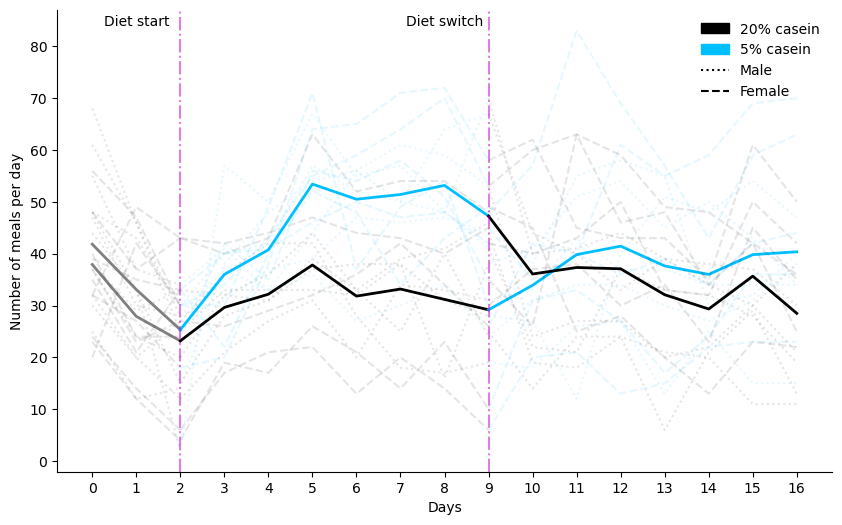

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/MEAL/meals_per_day_trend.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

# Plot function with male/female distinction and legend adjustments
def timeline_multicolor_combined_fig_with_sex(data_groups, sex_groups, colors=["black", "deepskyblue"], ylabel="Number of meals per day"):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each group with individual traces using dotted for males and dashed for females
    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        color_start, color_switch = colors if i == 0 else colors[::-1]  # Color order for each order

        # Iterate through individual traces with different styles for males and females
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)  # Grain phase
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)  # NR or PR phase
            ax.plot(range(9, 17), trace[9:], color=color_switch, linestyle=linestyle, alpha=0.1)  # PR or NR phase

        # Plot the combined mean line for each order
        mean_trace = np.mean(group, axis=0)
        ax.plot(range(3), mean_trace[:3], color="grey", linewidth=2)  # Grain phase (grey)
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2, label=f"Order {i + 1}")  # NR or PR phase
        ax.plot(range(9, 17), mean_trace[9:], color=color_switch, linewidth=2, label=f"Order {i + 1}")  # PR or NR phase

      # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, 84, "Diet start", ha='center')
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, 84, "Diet switch", ha='center')


    # Formatting
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Days")
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Remove grid
    ax.grid(False)

    # Add legend for NR and PR phases, as well as line styles for male and female
    NR_patch = mpatches.Patch(color=colors[0], label='20% casein')
    PR_patch = mpatches.Patch(color=colors[1], label='5% casein')
    male_line = mlines.Line2D([], [], color="black", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="black", linestyle='dashed', label='Female')
    
    ax.legend(handles=[NR_patch, PR_patch, male_line, female_line], loc='upper right', frameon=False)

    plt.show()

# Now plot using the correctly sequenced data with male/female differentiation
timeline_multicolor_combined_fig_with_sex([order_1_data, order_2_data], [order_1_sex, order_2_sex])


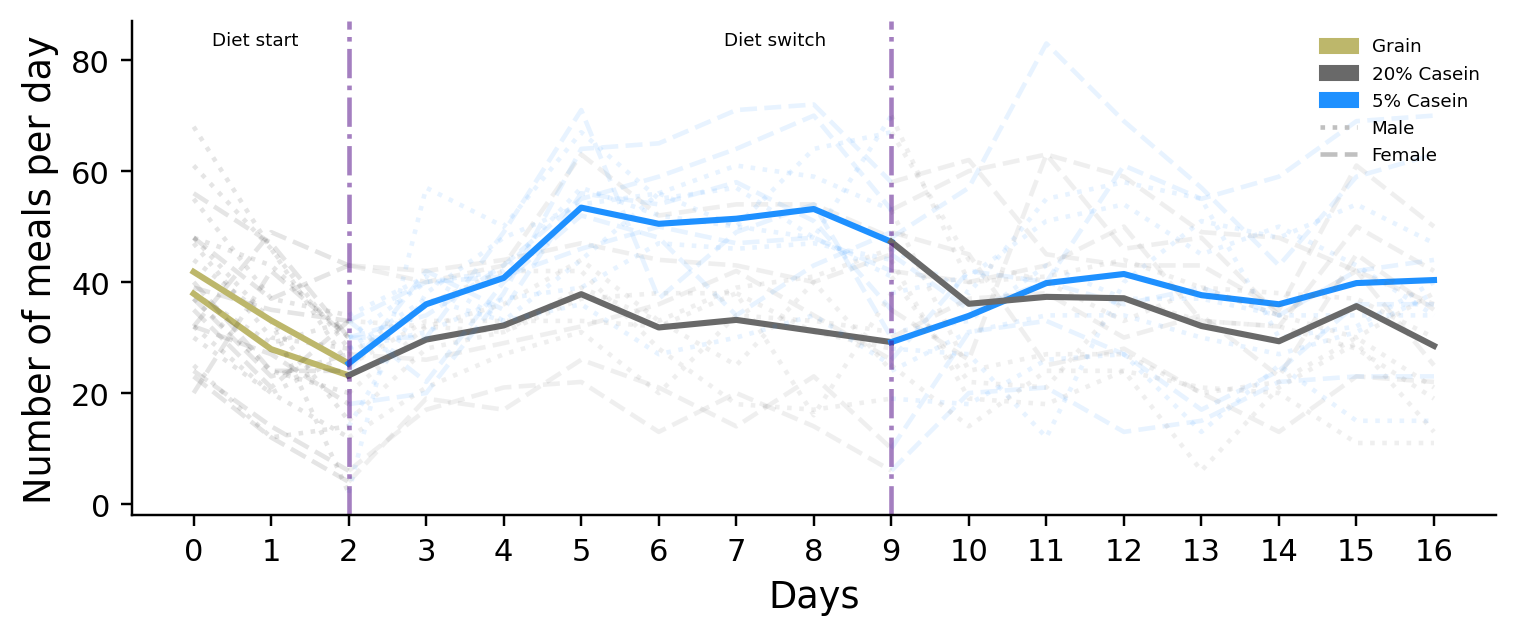

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/MEAL/meals_per_day_trend.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

def timeline_multicolor_combined_fig_with_sex(
    data_groups, 
    sex_groups, 
    colors=["dimgray", "dodgerblue"], 
    ylabel="Number of meals per day"
):
    """
    Create a multicolor timeline plot for meals per day with sex-distinguished line styles.
    The style is matched to the first snippet (pellets plot):
      - smaller figure size, 
      - black alpha lines for individual Grain phases, 
      - darkkhaki mean Grain line, 
      - dimgray and dodgerblue for second/third diet phases, 
      - dotted/dashed lines for M/F, 
      - vertical transition lines in indigo, etc.
    """

    fig, ax = plt.subplots(figsize=(7, 3), dpi=220)

    # Plot each group (Order 1 and Order 2) with individual traces using dotted for M and dashed for F
    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        # Pick which color is "second phase" vs. "third phase" for each order
        color_start, color_switch = colors if i == 0 else colors[::-1]

        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            # Grain phase: first 3 days in black
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)
            # Second phase: days 2 to 9
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)
            # Third phase: days 9 to 16
            ax.plot(range(9, 17), trace[9:17], color=color_switch, linestyle=linestyle, alpha=0.1)

        # Mean line for each order
        mean_trace = np.nanmean(group, axis=0)  # Use nanmean if there are NaNs
        # Grain phase mean in darkkhaki
        ax.plot(range(3), mean_trace[:3], color="darkkhaki", linewidth=2)
        # Second phase mean
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2,
                label=f"Order {i + 1}")
        # Third phase mean
        ax.plot(range(9, 17), mean_trace[9:17], color=color_switch, linewidth=2,
                label=f"Order {i + 1}")

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.5)
    # Adjust text position to your data range (y ~ top of your data)
    ax.text(0.8, max(ax.get_ylim())*0.95, "Diet start", ha='center', fontsize=6)
    
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.5)
    ax.text(7.5, max(ax.get_ylim())*0.95, "Diet switch", ha='center', fontsize=6)

    # Formatting
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Days", fontsize=12)
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # Build legend patches/lines
    Grain_patch = mpatches.Patch(color="darkkhaki", label='Grain')
    NR_patch    = mpatches.Patch(color=colors[0], label='20% Casein')
    PR_patch    = mpatches.Patch(color=colors[1], label='5% Casein')
    male_line   = mlines.Line2D([], [], color="silver", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="silver", linestyle='dashed', label='Female')

    # You can reorganize legend entries as needed
    ax.legend(
        handles=[Grain_patch, NR_patch, PR_patch, male_line, female_line],
        loc='upper right', 
        frameon=False, 
        fontsize=6
    )

    plt.tight_layout()
    return fig

# Now plot using the updated function
fig = timeline_multicolor_combined_fig_with_sex(
    [order_1_data, order_2_data],
    [order_1_sex, order_2_sex],
    ylabel="Number of meals per day"
)

# Optional: Save or show
# fig.savefig("path_to_save_plot.png", bbox_inches='tight', dpi=220)
plt.show()


fig.savefig("../plots/NEW_MEAL_PLOTS/line_plot_meals_per_day.png", bbox_inches='tight', dpi=220)

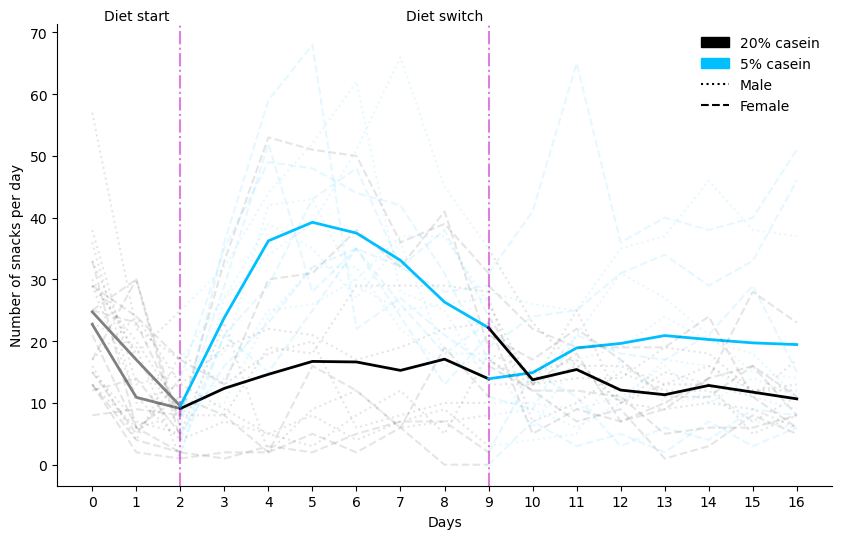

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/SNACK/snacks_per_day_trend.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

# Plot function with male/female distinction and legend adjustments
def timeline_multicolor_combined_fig_with_sex(data_groups, sex_groups, colors=["black", "deepskyblue"], ylabel="Number of snacks per day"):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each group with individual traces using dotted for males and dashed for females
    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        color_start, color_switch = colors if i == 0 else colors[::-1]  # Color order for each order

        # Iterate through individual traces with different styles for males and females
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)  # Grain phase
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)  # NR or PR phase
            ax.plot(range(9, 17), trace[9:], color=color_switch, linestyle=linestyle, alpha=0.1)  # PR or NR phase

        # Plot the combined mean line for each order
        mean_trace = np.mean(group, axis=0)
        ax.plot(range(3), mean_trace[:3], color="grey", linewidth=2)  # Grain phase (grey)
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2, label=f"Order {i + 1}")  # NR or PR phase
        ax.plot(range(9, 17), mean_trace[9:], color=color_switch, linewidth=2, label=f"Order {i + 1}")  # PR or NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, 72, "Diet start", ha='center')
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, 72, "Diet switch", ha='center')

    # Formatting
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Days")
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Remove grid
    ax.grid(False)

    # Add legend for NR and PR phases, as well as line styles for male and female
    NR_patch = mpatches.Patch(color=colors[0], label='20% casein')
    PR_patch = mpatches.Patch(color=colors[1], label='5% casein')
    male_line = mlines.Line2D([], [], color="black", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="black", linestyle='dashed', label='Female')
    
    ax.legend(handles=[NR_patch, PR_patch, male_line, female_line], loc='upper right', frameon=False)

    plt.show()

# Now plot using the correctly sequenced data with male/female differentiation
timeline_multicolor_combined_fig_with_sex([order_1_data, order_2_data], [order_1_sex, order_2_sex])


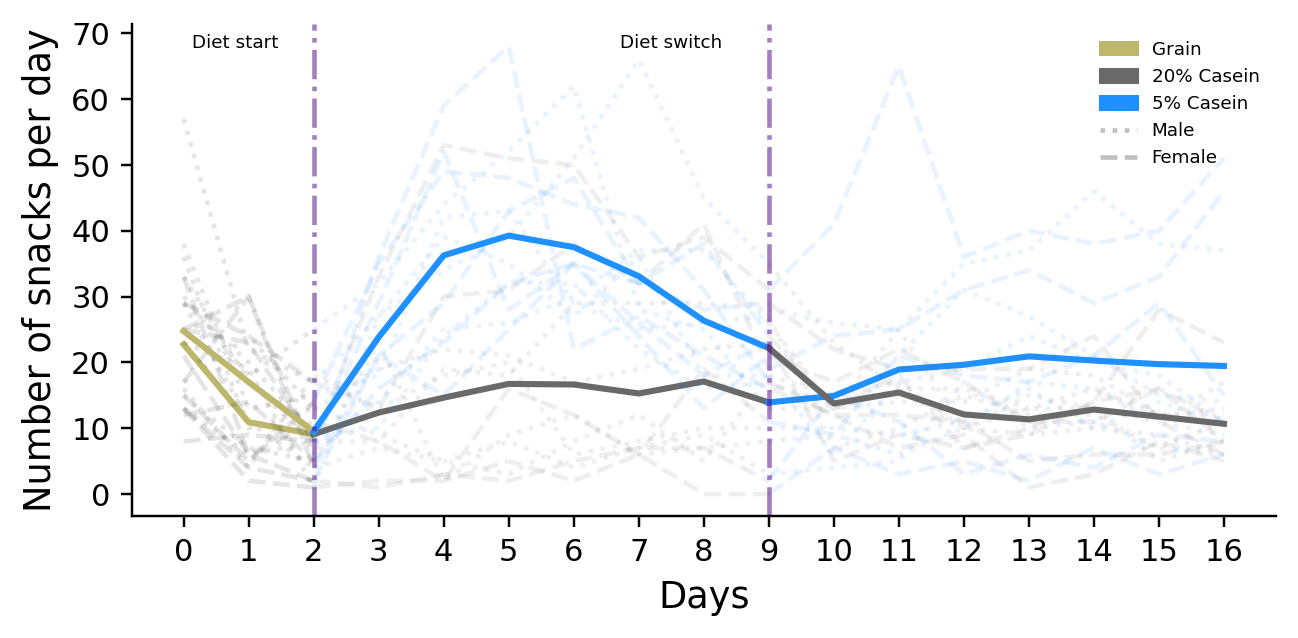

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/SNACK/snacks_per_day_trend.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

def timeline_multicolor_combined_fig_with_sex(
    data_groups, 
    sex_groups, 
    colors=["dimgray", "dodgerblue"], 
    ylabel="Number of snacks per day"
):
    """
    Create a multicolor timeline plot for snacks per day with sex-distinguished line styles,
    matching the style of the pellet-intake plot.
    """

    fig, ax = plt.subplots(figsize=(6, 3), dpi=220)

    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        # Determine color usage for each order
        color_start, color_switch = colors if i == 0 else colors[::-1]

        # Plot individual traces (dotted for M, dashed for F)
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            # Grain phase: 0-2
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)
            # Second phase: 2-9
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)
            # Third phase: 9-16
            ax.plot(range(9, 17), trace[9:17], color=color_switch, linestyle=linestyle, alpha=0.1)

        # Mean line for each order
        mean_trace = np.nanmean(group, axis=0)
        ax.plot(range(3), mean_trace[:3], color="darkkhaki", linewidth=2)   # Grain mean
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2,
                label=f"Order {i+1}")
        ax.plot(range(9, 17), mean_trace[9:17], color=color_switch, linewidth=2,
                label=f"Order {i+1}")

    # Vertical lines for diet-phase transitions
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.5)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.5)

    # Place transition text near the top of the Y-range
    y_top = max(ax.get_ylim()) * 0.95
    ax.text(0.8, y_top, "Diet start", ha='center', fontsize=6)
    ax.text(7.5, y_top, "Diet switch", ha='center', fontsize=6)

    # Formatting
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Days", fontsize=12)
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # Legend elements
    Grain_patch = mpatches.Patch(color="darkkhaki", label='Grain')
    NR_patch    = mpatches.Patch(color=colors[0], label='20% Casein')
    PR_patch    = mpatches.Patch(color=colors[1], label='5% Casein')
    male_line   = mlines.Line2D([], [], color="silver", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="silver", linestyle='dashed', label='Female')

    ax.legend(handles=[Grain_patch, NR_patch, PR_patch, male_line, female_line],
              loc='upper right', frameon=False, fontsize=6)

    plt.tight_layout()
    return fig

# Now plot using the updated function
fig = timeline_multicolor_combined_fig_with_sex(
    [order_1_data, order_2_data], 
    [order_1_sex, order_2_sex], 
    ylabel="Number of snacks per day"
)

# Optional: Save or just show
# fig.savefig("path_to_save_snacks_plot.png", bbox_inches='tight', dpi=220)
plt.show()


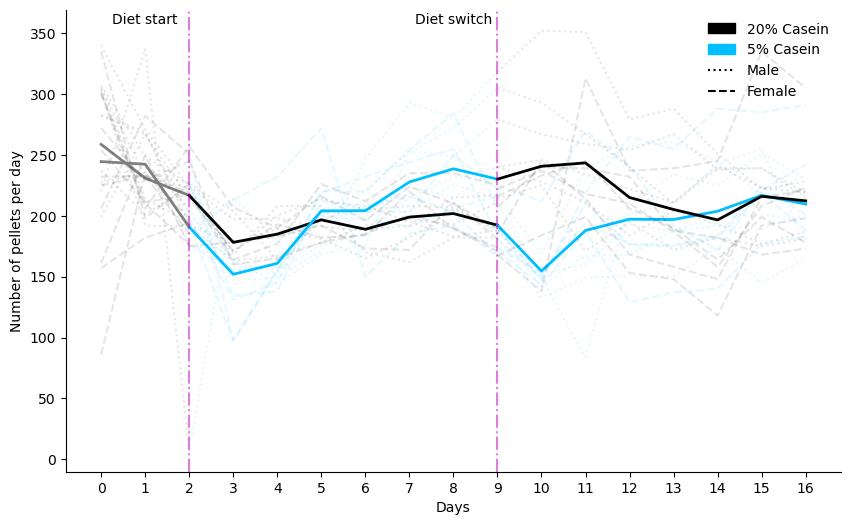

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/PELLET_INTAKE/pellets_trend.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

# Plot function with male/female distinction and legend adjustments
def timeline_multicolor_combined_fig_with_sex(data_groups, sex_groups, colors=["black", "deepskyblue"], ylabel="Number of pellets per day"):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each group with individual traces using dotted for males and dashed for females
    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        color_start, color_switch = colors if i == 0 else colors[::-1]  # Color order for each order

        # Iterate through individual traces with different styles for males and females
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)  # Grain phase
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)  # NR or PR phase
            ax.plot(range(9, 17), trace[9:], color=color_switch, linestyle=linestyle, alpha=0.1)  # PR or NR phase

        # Plot the combined mean line for each order
        mean_trace = np.mean(group, axis=0)
        ax.plot(range(3), mean_trace[:3], color="grey", linewidth=2)  # Grain phase (grey)
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2, label=f"Order {i + 1}")  # NR or PR phase
        ax.plot(range(9, 17), mean_trace[9:], color=color_switch, linewidth=2, label=f"Order {i + 1}")  # PR or NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, 358, "Diet start", ha='center')
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, 358, "Diet switch", ha='center')


    # Formatting
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Days")
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Remove grid
    ax.grid(False)

    # Add legend for NR and PR phases, as well as line styles for male and female
    NR_patch = mpatches.Patch(color=colors[0], label='20% Casein')
    PR_patch = mpatches.Patch(color=colors[1], label='5% Casein')
    male_line = mlines.Line2D([], [], color="black", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="black", linestyle='dashed', label='Female')
    
    ax.legend(handles=[NR_patch, PR_patch, male_line, female_line], loc='upper right', frameon=False)

    plt.show()

# Now plot using the correctly sequenced data with male/female differentiation
timeline_multicolor_combined_fig_with_sex([order_1_data, order_2_data], [order_1_sex, order_2_sex])


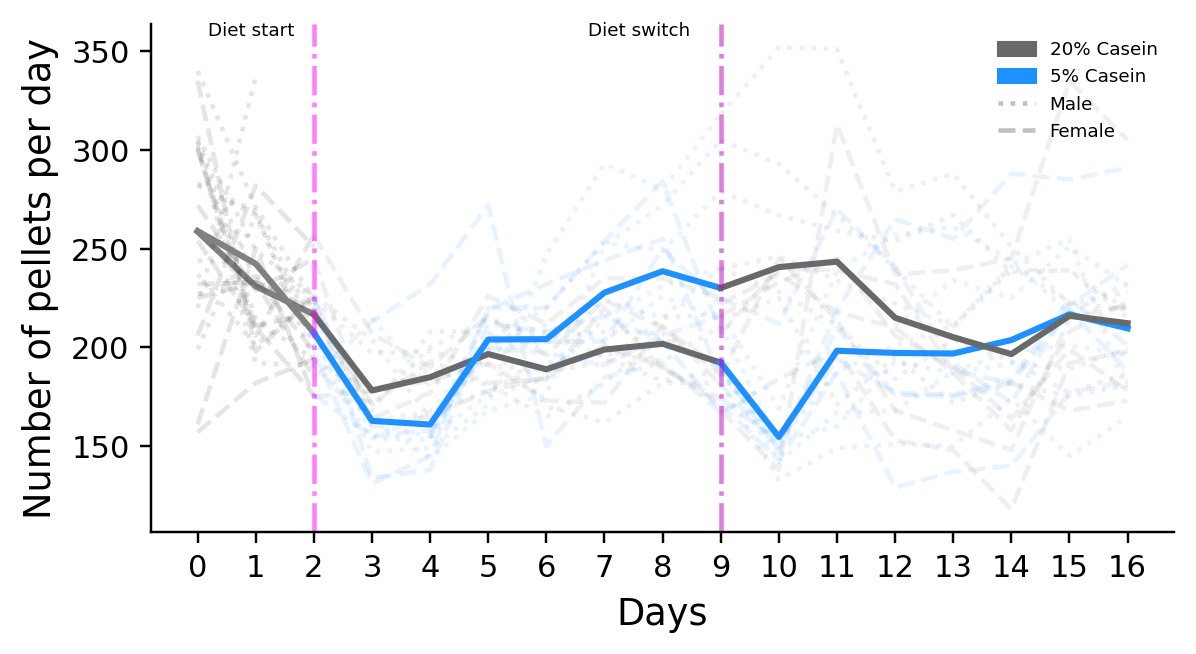

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/PELLET_INTAKE/pellets_trend.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

# Function to filter and mask data below a threshold
def mask_below_threshold(data, threshold=100):
    return np.where(data >= threshold, data, np.nan)

# Apply the threshold filter to the data
threshold = 100
order_1_data = mask_below_threshold(order_1_data, threshold)
order_2_data = mask_below_threshold(order_2_data, threshold)

# Plot function with male/female distinction and legend adjustments
def timeline_multicolor_combined_fig_with_sex(data_groups, sex_groups, colors=["dimgray", "dodgerblue"], ylabel="Number of pellets per day"):
    fig, ax = plt.subplots(figsize=(6, 3), dpi=220)
    

    # Plot each group with individual traces using dotted for males and dashed for females
    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        color_start, color_switch = colors if i == 0 else colors[::-1]  # Color order for each order

        # Iterate through individual traces with different styles for males and females
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)  # Grain phase
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)  # NR or PR phase
            ax.plot(range(9, 17), trace[9:], color=color_switch, linestyle=linestyle, alpha=0.1)  # PR or NR phase

        # Plot the combined mean line for each order
        mean_trace = np.nanmean(group, axis=0)  # Use nanmean to ignore NaNs
        ax.plot(range(3), mean_trace[:3], color="grey", linewidth=2)  # Grain phase (grey)
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2, label=f"Order {i + 1}")  # NR or PR phase
        ax.plot(range(9, 17), mean_trace[9:], color=color_switch, linewidth=2, label=f"Order {i + 1}")  # PR or NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="magenta", alpha=0.5)
    ax.text(0.92, 358, "Diet start", ha='center', fontsize=6)
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(7.6, 358, "Diet switch", ha='center', fontsize=6)

    # Formatting
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Days", fontsize=12)
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Remove grid
    ax.grid(False)

    # Add legend for NR and PR phases, as well as line styles for male and female
    NR_patch = mpatches.Patch(color=colors[0], label='20% Casein')
    PR_patch = mpatches.Patch(color=colors[1], label='5% Casein')
    male_line = mlines.Line2D([], [], color="silver", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="silver", linestyle='dashed', label='Female')
    
    ax.legend(handles=[NR_patch, PR_patch, male_line, female_line], loc='upper right', frameon=False, fontsize=6)
    return fig

    plt.show()

# Now plot using the correctly sequenced data with male/female differentiation
fig=timeline_multicolor_combined_fig_with_sex([order_1_data, order_2_data], [order_1_sex, order_2_sex])



# Save the figure
#fig.savefig("../plots/NEW_MEAL_PLOTS/line_plot_pellet_total.png", bbox_inches='tight', dpi=220)

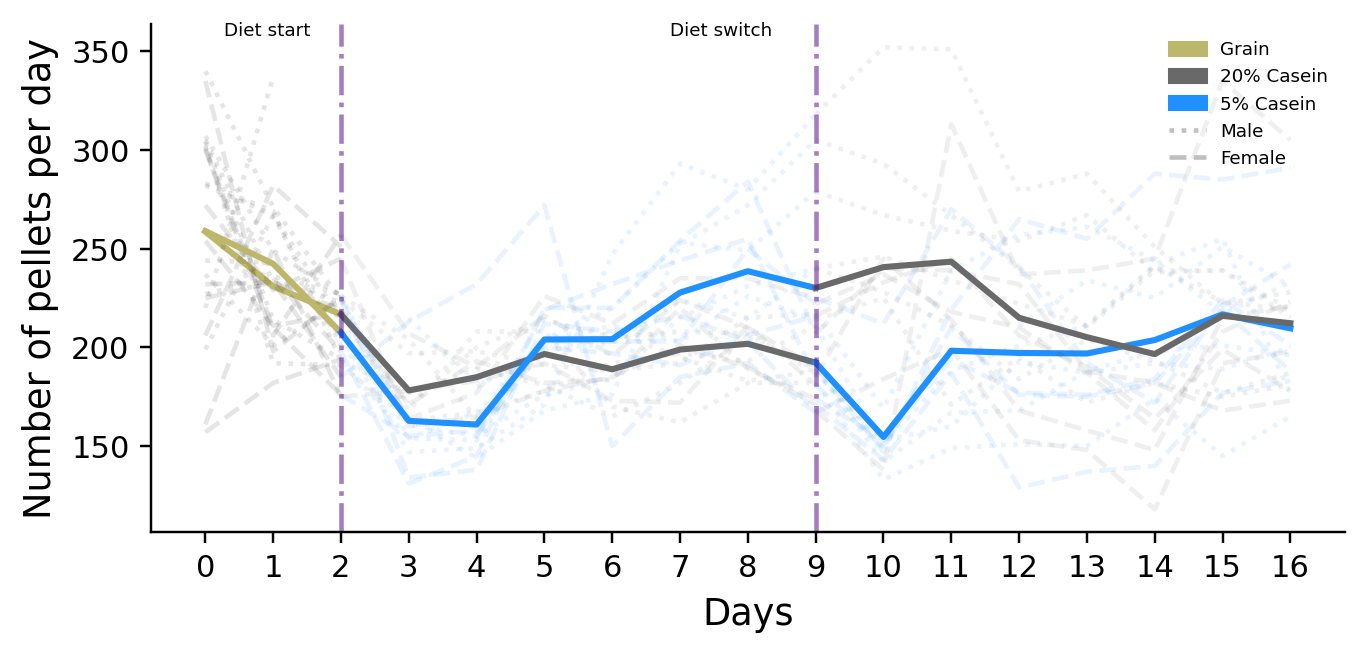

In [64]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/PELLET_INTAKE/pellets_trend.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

# Function to filter and mask data below a threshold
def mask_below_threshold(data, threshold=100):
    return np.where(data >= threshold, data, np.nan)

# Apply the threshold filter to the data
threshold = 100
order_1_data = mask_below_threshold(order_1_data, threshold)
order_2_data = mask_below_threshold(order_2_data, threshold)

# Add legend for Grain phase along with NR and PR phases, as well as line styles for male and female
def timeline_multicolor_combined_fig_with_sex(data_groups, sex_groups, colors=["dimgray", "dodgerblue"], ylabel="Number of pellets per day"):
    fig, ax = plt.subplots(figsize=(7, 3), dpi=220)

    # Plot each group with individual traces using dotted for males and dashed for females
    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        color_start, color_switch = colors if i == 0 else colors[::-1]  # Color order for each order

        # Iterate through individual traces with different styles for males and females
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)  # Grain phase
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)  # NR or PR phase
            ax.plot(range(9, 17), trace[9:], color=color_switch, linestyle=linestyle, alpha=0.1)  # PR or NR phase

        # Plot the combined mean line for each order
        mean_trace = np.nanmean(group, axis=0)  # Use nanmean to ignore NaNs
        ax.plot(range(3), mean_trace[:3], color="darkkhaki", linewidth=2)  # Grain phase (green)
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2, label=f"Order {i + 1}")  # NR or PR phase
        ax.plot(range(9, 17), mean_trace[9:], color=color_switch, linewidth=2, label=f"Order {i + 1}")  # PR or NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.5)
    ax.text(0.92, 358, "Diet start", ha='center', fontsize=6)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.5)
    ax.text(7.6, 358, "Diet switch", ha='center', fontsize=6)

    # Formatting
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Days", fontsize=12)
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Remove grid
    ax.grid(False)

    # Add legend for Grain, NR, and PR phases, as well as line styles for male and female
    Grain_patch = mpatches.Patch(color="darkkhaki", label='Grain')
    NR_patch = mpatches.Patch(color=colors[0], label='20% Casein')
    PR_patch = mpatches.Patch(color=colors[1], label='5% Casein')
    male_line = mlines.Line2D([], [], color="silver", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="silver", linestyle='dashed', label='Female')
    
    ax.legend(handles=[Grain_patch, NR_patch, PR_patch, male_line, female_line], loc='upper right', frameon=False, fontsize=6)
    return fig

    plt.show()

# Plot the updated figure
fig = timeline_multicolor_combined_fig_with_sex([order_1_data, order_2_data], [order_1_sex, order_2_sex])

# Save the figure
fig.savefig("../plots/NEW_MEAL_PLOTS/line_plot_pellet_total.png", bbox_inches='tight', dpi=220)









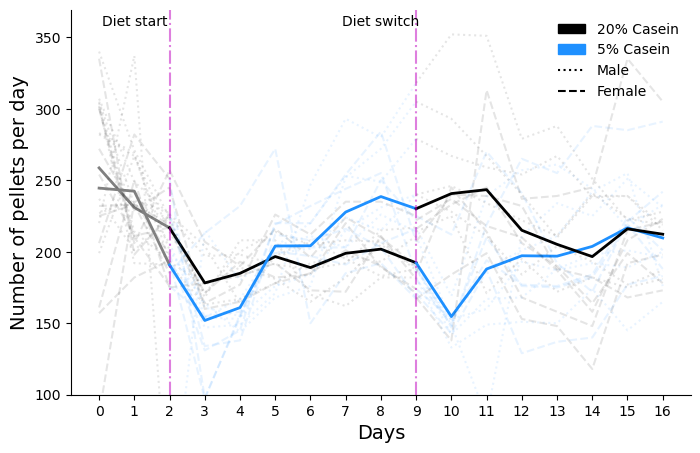

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/PELLET_INTAKE/pellets_trend.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

# Plot function with male/female distinction and legend adjustments
def timeline_multicolor_combined_fig_with_sex(data_groups, sex_groups, colors=["black", "dodgerblue"], ylabel="Number of pellets per day", threshold=100):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot each group with individual traces using dotted for males and dashed for females
    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        color_start, color_switch = colors if i == 0 else colors[::-1]  # Color order for each order

        # Iterate through individual traces with different styles for males and females
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)  # Grain phase
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)  # NR or PR phase
            ax.plot(range(9, 17), trace[9:], color=color_switch, linestyle=linestyle, alpha=0.1)  # PR or NR phase

        # Plot the combined mean line for each order
        mean_trace = np.mean(group, axis=0)
        ax.plot(range(3), mean_trace[:3], color="olive", linewidth=2)  # Grain phase (grey)
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2, label=f"Order {i + 1}")  # NR or PR phase
        ax.plot(range(9, 17), mean_trace[9:], color=color_switch, linewidth=2, label=f"Order {i + 1}")  # PR or NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, 358, "Diet start", ha='center')
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, 358, "Diet switch", ha='center')

    # Formatting
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlabel("Days", fontsize=14)
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(bottom=threshold)  # Set y-axis lower limit to threshold
    
    # Remove grid
    ax.grid(False)

    # Add legend for NR and PR phases, as well as line styles for male and female
    NR_patch = mpatches.Patch(color=colors[0], label='20% Casein')
    PR_patch = mpatches.Patch(color=colors[1], label='5% Casein')
    male_line = mlines.Line2D([], [], color="black", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="black", linestyle='dashed', label='Female')
    
    ax.legend(handles=[NR_patch, PR_patch, male_line, female_line], loc='upper right', frameon=False)

    plt.show()

# Now plot using the correctly sequenced data with male/female differentiation
timeline_multicolor_combined_fig_with_sex([order_1_data, order_2_data], [order_1_sex, order_2_sex])


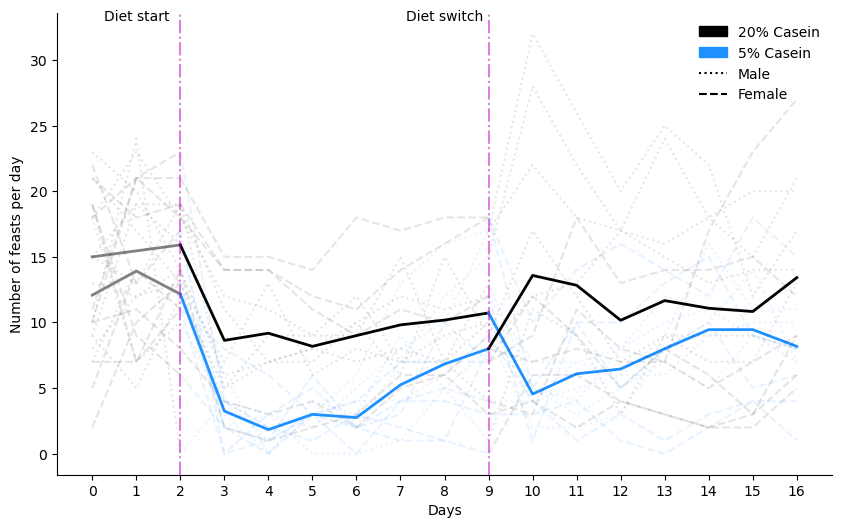

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/FEAST/mega_meals_per_day_trend.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

# Plot function with male/female distinction and legend adjustments
def timeline_multicolor_combined_fig_with_sex(data_groups, sex_groups, colors=["black", "dodgerblue"], ylabel="Number of feasts per day"):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each group with individual traces using dotted for males and dashed for females
    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        color_start, color_switch = colors if i == 0 else colors[::-1]  # Color order for each order

        # Iterate through individual traces with different styles for males and females
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)  # Grain phase
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)  # NR or PR phase
            ax.plot(range(9, 17), trace[9:], color=color_switch, linestyle=linestyle, alpha=0.1)  # PR or NR phase

        # Plot the combined mean line for each order
        mean_trace = np.mean(group, axis=0)
        ax.plot(range(3), mean_trace[:3], color="grey", linewidth=2)  # Grain phase (grey)
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2, label=f"Order {i + 1}")  # NR or PR phase
        ax.plot(range(9, 17), mean_trace[9:], color=color_switch, linewidth=2, label=f"Order {i + 1}")  # PR or NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, 33, "Diet start", ha='center')
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, 33, "Diet switch", ha='center')


    # Formatting
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Days")
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Remove grid
    ax.grid(False)

    # Add legend for NR and PR phases, as well as line styles for male and female
    NR_patch = mpatches.Patch(color=colors[0], label='20% Casein')
    PR_patch = mpatches.Patch(color=colors[1], label='5% Casein')
    male_line = mlines.Line2D([], [], color="black", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="black", linestyle='dashed', label='Female')
    
    ax.legend(handles=[NR_patch, PR_patch, male_line, female_line], loc='upper right', frameon=False)

    plt.show()

# Now plot using the correctly sequenced data with male/female differentiation
timeline_multicolor_combined_fig_with_sex([order_1_data, order_2_data], [order_1_sex, order_2_sex])


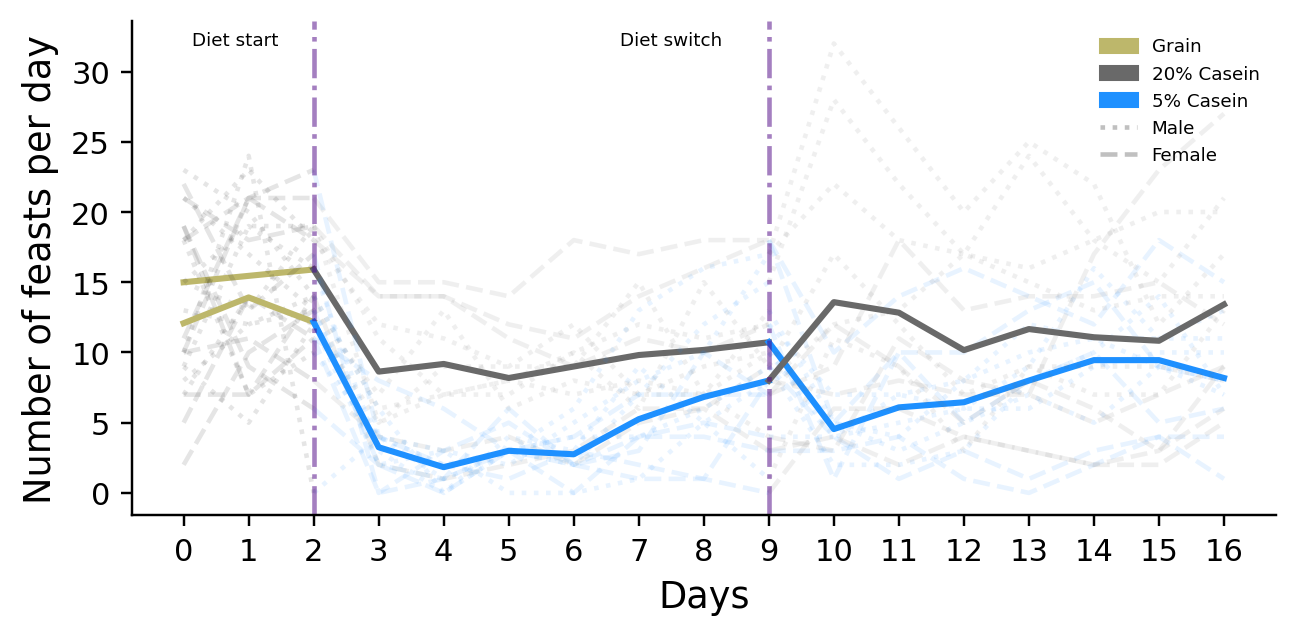

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/FEAST/mega_meals_per_day_trend.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

def timeline_multicolor_combined_fig_with_sex(
    data_groups, 
    sex_groups, 
    colors=["dimgray", "dodgerblue"], 
    ylabel="Number of feasts per day"
):
    """
    Create a multicolor timeline plot for 'feasts per day' with sex-distinguished line styles,
    matching the style used in the other line plots.
    """

    fig, ax = plt.subplots(figsize=(6, 3), dpi=220)

    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        # For Order 1, color = [dimgray, dodgerblue]; for Order 2, reversed
        color_start, color_switch = colors if i == 0 else colors[::-1]

        # Plot individual traces: dotted = M, dashed = F
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            # Grain phase: days 0-2 in black
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)
            # Second phase: days 2-9
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)
            # Third phase: days 9-16
            ax.plot(range(9, 17), trace[9:17], color=color_switch, linestyle=linestyle, alpha=0.1)

        # Mean line for each order
        mean_trace = np.nanmean(group, axis=0)
        # Grain mean line in darkkhaki
        ax.plot(range(3), mean_trace[:3], color="darkkhaki", linewidth=2)
        # Second phase mean
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2,
                label=f"Order {i + 1}")
        # Third phase mean
        ax.plot(range(9, 17), mean_trace[9:17], color=color_switch, linewidth=2,
                label=f"Order {i + 1}")

    # Vertical lines for phase transitions
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.5)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.5)

    # Place text near top
    y_top = max(ax.get_ylim()) * 0.95
    ax.text(0.8, y_top, "Diet start", ha='center', fontsize=6)
    ax.text(7.5, y_top, "Diet switch", ha='center', fontsize=6)

    # Axes labels and ticks
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Days", fontsize=12)
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # Legend
    Grain_patch = mpatches.Patch(color="darkkhaki", label='Grain')
    NR_patch    = mpatches.Patch(color=colors[0], label='20% Casein')
    PR_patch    = mpatches.Patch(color=colors[1], label='5% Casein')
    male_line   = mlines.Line2D([], [], color="silver", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="silver", linestyle='dashed', label='Female')

    ax.legend(handles=[Grain_patch, NR_patch, PR_patch, male_line, female_line],
              loc='upper right', frameon=False, fontsize=6)

    plt.tight_layout()
    return fig

# Now plot using the updated function
fig = timeline_multicolor_combined_fig_with_sex(
    [order_1_data, order_2_data], 
    [order_1_sex, order_2_sex], 
    ylabel="Number of feasts per day"
)

# Optionally save the figure or just show it
# fig.savefig("path_to_save_feasts_plot.png", bbox_inches='tight', dpi=220)
plt.show()


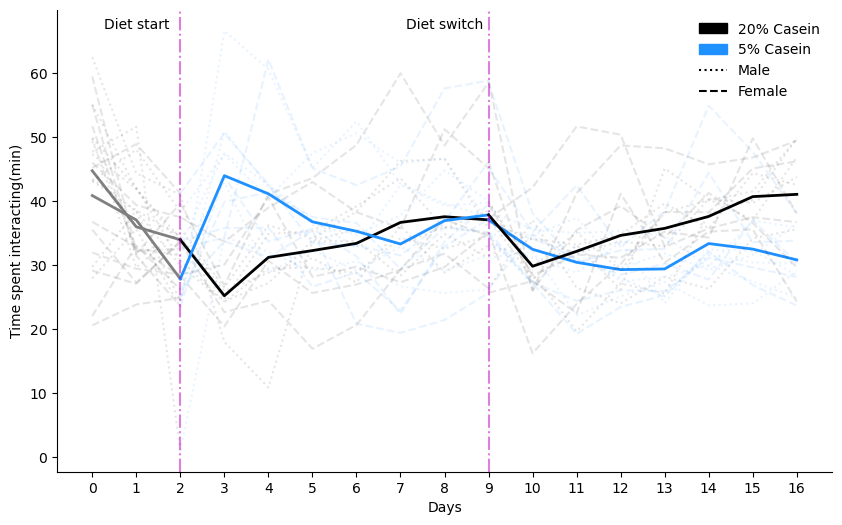

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/INTERACTION_TIME/INTER_TIME.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

# Plot function with male/female distinction and legend adjustments
def timeline_multicolor_combined_fig_with_sex(data_groups, sex_groups, colors=["black", "dodgerblue"], ylabel="Time spent interacting(min)"):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each group with individual traces using dotted for males and dashed for females
    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        color_start, color_switch = colors if i == 0 else colors[::-1]  # Color order for each order

        # Iterate through individual traces with different styles for males and females
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)  # Grain phase
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)  # NR or PR phase
            ax.plot(range(9, 17), trace[9:], color=color_switch, linestyle=linestyle, alpha=0.1)  # PR or NR phase

        # Plot the combined mean line for each order
        mean_trace = np.mean(group, axis=0)
        ax.plot(range(3), mean_trace[:3], color="grey", linewidth=2)  # Grain phase (grey)
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2, label=f"Order {i + 1}")  # NR or PR phase
        ax.plot(range(9, 17), mean_trace[9:], color=color_switch, linewidth=2, label=f"Order {i + 1}")  # PR or NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, 67, "Diet start", ha='center')
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, 67, "Diet switch", ha='center')


    # Formatting
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Days")
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Remove grid
    ax.grid(False)

    # Add legend for NR and PR phases, as well as line styles for male and female
    NR_patch = mpatches.Patch(color=colors[0], label='20% Casein')
    PR_patch = mpatches.Patch(color=colors[1], label='5% Casein')
    male_line = mlines.Line2D([], [], color="black", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="black", linestyle='dashed', label='Female')
    
    ax.legend(handles=[NR_patch, PR_patch, male_line, female_line], loc='upper right', frameon=False)

    plt.show()

# Now plot using the correctly sequenced data with male/female differentiation
timeline_multicolor_combined_fig_with_sex([order_1_data, order_2_data], [order_1_sex, order_2_sex])


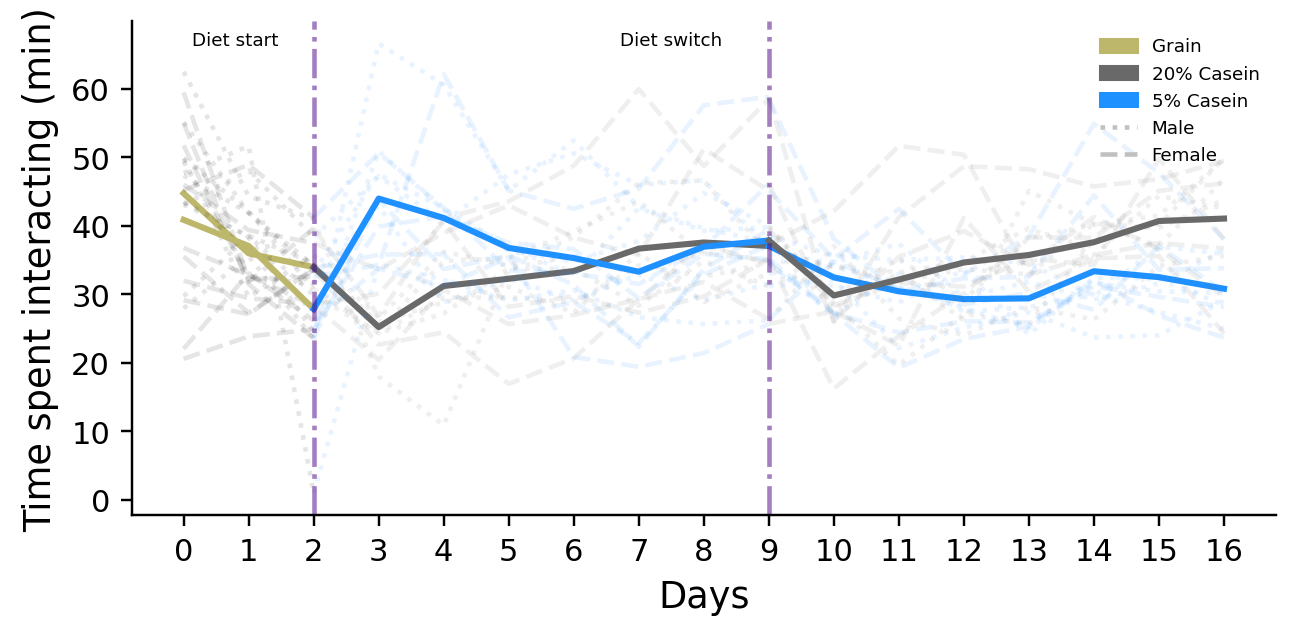

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/INTERACTION_TIME/INTER_TIME.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

def timeline_multicolor_combined_fig_with_sex(
    data_groups, 
    sex_groups, 
    colors=["dimgray", "dodgerblue"], 
    ylabel="Time spent interacting (min)"
):
    """
    Create a multicolor timeline plot for 'Time spent interacting' with
    sex-distinguished line styles, matching the style from other line plots.
    """

    fig, ax = plt.subplots(figsize=(6, 3), dpi=220)

    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        # For Order 1, color = [dimgray, dodgerblue]; for Order 2, reversed
        color_start, color_switch = colors if i == 0 else colors[::-1]

        # Plot individual traces: dotted = M, dashed = F
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            # Grain phase (days 0-2) in black
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)
            # Second phase (days 2-9)
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)
            # Third phase (days 9-16)
            ax.plot(range(9, 17), trace[9:17], color=color_switch, linestyle=linestyle, alpha=0.1)

        # Mean line for each order
        mean_trace = np.nanmean(group, axis=0)
        # Grain mean in darkkhaki
        ax.plot(range(3), mean_trace[:3], color="darkkhaki", linewidth=2)
        # Second phase mean
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2,
                label=f"Order {i + 1}")
        # Third phase mean
        ax.plot(range(9, 17), mean_trace[9:17], color=color_switch, linewidth=2,
                label=f"Order {i + 1}")

    # Vertical lines for phase transitions
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.5)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.5)

    # Text annotations near the top of the y-range
    y_top = max(ax.get_ylim()) * 0.95
    ax.text(0.8, y_top, "Diet start", ha='center', fontsize=6)
    ax.text(7.5, y_top, "Diet switch", ha='center', fontsize=6)

    # Formatting
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Days", fontsize=12)
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # Legend
    Grain_patch = mpatches.Patch(color="darkkhaki", label='Grain')
    NR_patch    = mpatches.Patch(color=colors[0], label='20% Casein')
    PR_patch    = mpatches.Patch(color=colors[1], label='5% Casein')
    male_line   = mlines.Line2D([], [], color="silver", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="silver", linestyle='dashed', label='Female')

    ax.legend(handles=[Grain_patch, NR_patch, PR_patch, male_line, female_line],
              loc='upper right', frameon=False, fontsize=6)

    plt.tight_layout()
    return fig

# Now plot using the updated function
fig = timeline_multicolor_combined_fig_with_sex(
    [order_1_data, order_2_data], 
    [order_1_sex, order_2_sex], 
    ylabel="Time spent interacting (min)"
)

# fig.savefig("path_to_save_interaction_plot.png", bbox_inches='tight', dpi=220)
plt.show()


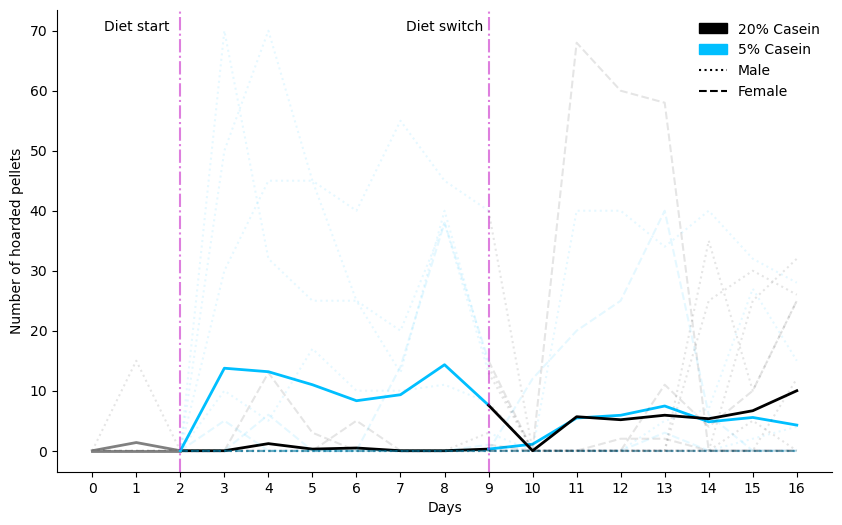

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/Hoarding/HOARDING.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

# Plot function with male/female distinction and legend adjustments
def timeline_multicolor_combined_fig_with_sex(data_groups, sex_groups, colors=["black", "deepskyblue"], ylabel="Number of hoarded pellets"):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each group with individual traces using dotted for males and dashed for females
    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        color_start, color_switch = colors if i == 0 else colors[::-1]  # Color order for each order

        # Iterate through individual traces with different styles for males and females
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)  # Grain phase
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)  # NR or PR phase
            ax.plot(range(9, 17), trace[9:], color=color_switch, linestyle=linestyle, alpha=0.1)  # PR or NR phase

        # Plot the combined mean line for each order
        mean_trace = np.mean(group, axis=0)
        ax.plot(range(3), mean_trace[:3], color="grey", linewidth=2)  # Grain phase (grey)
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2, label=f"Order {i + 1}")  # NR or PR phase
        ax.plot(range(9, 17), mean_trace[9:], color=color_switch, linewidth=2, label=f"Order {i + 1}")  # PR or NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, 70, "Diet start", ha='center')
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, 70, "Diet switch", ha='center')


    # Formatting
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Days")
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Remove grid
    ax.grid(False)

    # Add legend for NR and PR phases, as well as line styles for male and female
    NR_patch = mpatches.Patch(color=colors[0], label='20% Casein')
    PR_patch = mpatches.Patch(color=colors[1], label='5% Casein')
    male_line = mlines.Line2D([], [], color="black", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="black", linestyle='dashed', label='Female')
    
    ax.legend(handles=[NR_patch, PR_patch, male_line, female_line], loc='upper right', frameon=False)

    plt.show()

# Now plot using the correctly sequenced data with male/female differentiation
timeline_multicolor_combined_fig_with_sex([order_1_data, order_2_data], [order_1_sex, order_2_sex])


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/Bodyweight/BODYWEIGHT.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for Order 1: Grain -> NR -> PR
order_1_data = meals_per_day_data[meals_per_day_data["Order"] == 1][grain_cols + nr_cols + pr_cols].values
order_1_sex = meals_per_day_data[meals_per_day_data["Order"] == 1]["Sex"].values

# Arrange data for Order 2: Grain -> PR -> NR
order_2_data = meals_per_day_data[meals_per_day_data["Order"] == 2][grain_cols + pr_cols + nr_cols].values
order_2_sex = meals_per_day_data[meals_per_day_data["Order"] == 2]["Sex"].values

# Plot function with male/female distinction and legend adjustments
def timeline_multicolor_combined_fig_with_sex(data_groups, sex_groups, colors=["black", "deepskyblue"], ylabel="Bodyweight (g)"):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each group with individual traces using dotted for males and dashed for females
    for i, (group, sex_group) in enumerate(zip(data_groups, sex_groups)):
        color_start, color_switch = colors if i == 0 else colors[::-1]  # Color order for each order

        # Iterate through individual traces with different styles for males and females
        for trace, sex in zip(group, sex_group):
            linestyle = 'dotted' if sex == "M" else 'dashed'
            ax.plot(range(3), trace[:3], color="black", linestyle=linestyle, alpha=0.1)  # Grain phase
            ax.plot(range(2, 10), trace[2:10], color=color_start, linestyle=linestyle, alpha=0.1)  # NR or PR phase
            ax.plot(range(9, 17), trace[9:], color=color_switch, linestyle=linestyle, alpha=0.1)  # PR or NR phase

        # Plot the combined mean line for each order
        mean_trace = np.mean(group, axis=0)
        ax.plot(range(3), mean_trace[:3], color="grey", linewidth=2)  # Grain phase (grey)
        ax.plot(range(2, 10), mean_trace[2:10], color=color_start, linewidth=2, label=f"Order {i + 1}")  # NR or PR phase
        ax.plot(range(9, 17), mean_trace[9:], color=color_switch, linewidth=2, label=f"Order {i + 1}")  # PR or NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, 28, "Diet start", ha='center')
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, 28, "Diet switch", ha='center')


    # Formatting
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Days")
    ax.set_xticks(range(17))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Remove grid
    ax.grid(False)

    # Add legend for NR and PR phases, as well as line styles for male and female
    NR_patch = mpatches.Patch(color=colors[0], label='20% Casein')
    PR_patch = mpatches.Patch(color=colors[1], label='5% Casein')
    male_line = mlines.Line2D([], [], color="black", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="black", linestyle='dashed', label='Female')
    
    ax.legend(handles=[NR_patch, PR_patch, male_line, female_line], loc='upper right', frameon=False)

    plt.show()

# Now plot using the correctly sequenced data with male/female differentiation
timeline_multicolor_combined_fig_with_sex([order_1_data, order_2_data], [order_1_sex, order_2_sex])


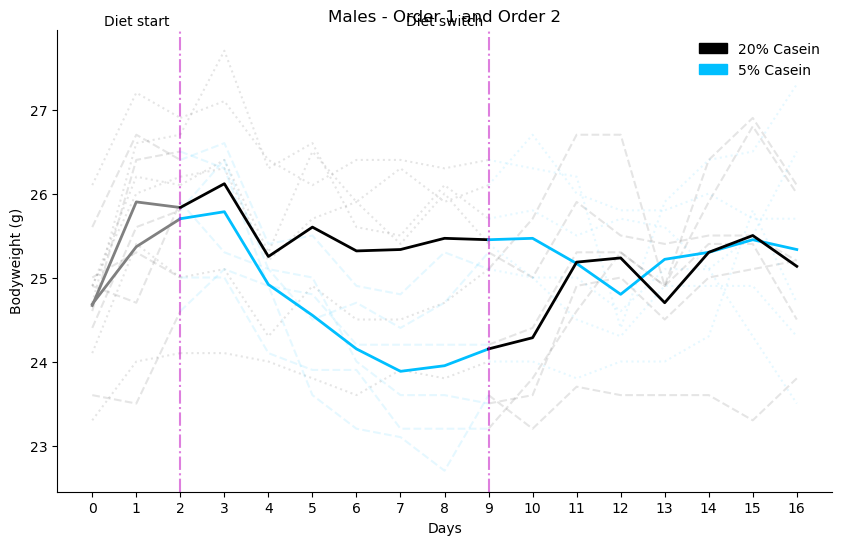

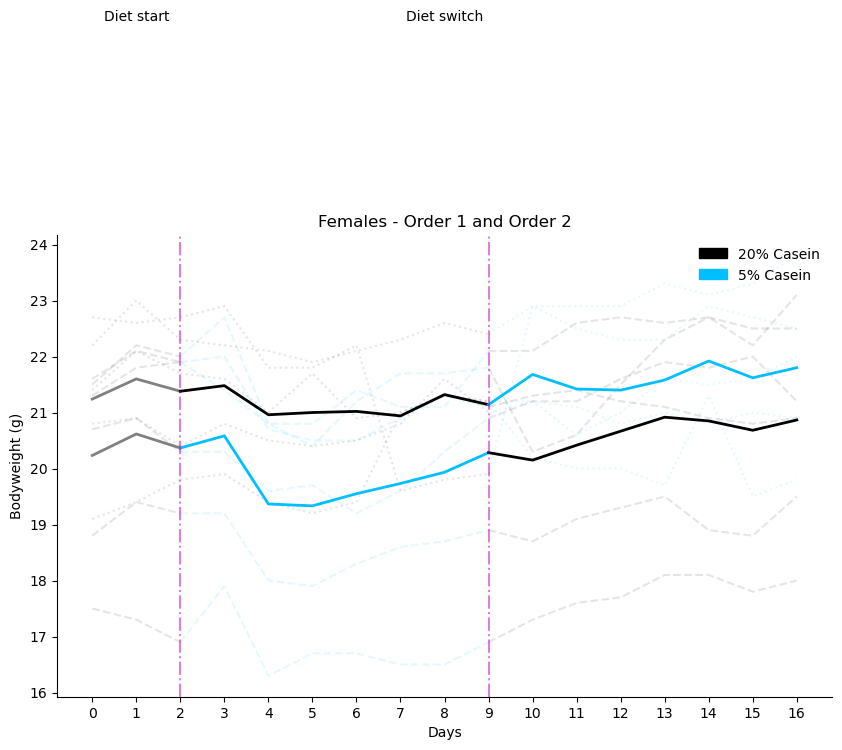

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/Bodyweight/BODYWEIGHT.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for each sex and order
def get_order_data(order, sex):
    data = meals_per_day_data[(meals_per_day_data["Order"] == order) & (meals_per_day_data["Sex"] == sex)]
    if order == 1:
        return data[grain_cols + nr_cols + pr_cols].values  # Order 1: Grain -> NR -> PR
    else:
        return data[grain_cols + pr_cols + nr_cols].values  # Order 2: Grain -> PR -> NR

male_order_1 = get_order_data(1, "M")
male_order_2 = get_order_data(2, "M")
female_order_1 = get_order_data(1, "F")
female_order_2 = get_order_data(2, "F")

# Function to plot data for a single sex, with both orders in one figure
def plot_by_sex(data_order1, data_order2, color_order1_phase1, color_order1_phase2, color_order2_phase1, color_order2_phase2, title):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each individual trace for Order 1 (20% Casein -> 5% Casein)
    for trace in data_order1:
        ax.plot(range(3), trace[:3], color="black", linestyle='dotted', alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order1_phase1, linestyle='dotted', alpha=0.1)  # NR phase (20% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order1_phase2, linestyle='dotted', alpha=0.1)  # PR phase (5% Casein)

    # Plot each individual trace for Order 2 (5% Casein -> 20% Casein)
    for trace in data_order2:
        ax.plot(range(3), trace[:3], color="black", linestyle='dashed', alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order2_phase1, linestyle='dashed', alpha=0.1)  # PR phase (5% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order2_phase2, linestyle='dashed', alpha=0.1)  # NR phase (20% Casein)

    # Plot the combined mean lines for Order 1 and Order 2
    mean_trace_order1 = np.mean(data_order1, axis=0)
    mean_trace_order2 = np.mean(data_order2, axis=0)
    
    # Order 1 mean lines (20% Casein -> 5% Casein)
    ax.plot(range(3), mean_trace_order1[:3], color="grey", linewidth=2)  # Grain phase (grey)
    ax.plot(range(2, 10), mean_trace_order1[2:10], color=color_order1_phase1, linewidth=2, label="Order 1")  # NR phase
    ax.plot(range(9, 17), mean_trace_order1[9:], color=color_order1_phase2, linewidth=2)  # PR phase
    
    # Order 2 mean lines (5% Casein -> 20% Casein)
    ax.plot(range(3), mean_trace_order2[:3], color="grey", linewidth=2)
    ax.plot(range(2, 10), mean_trace_order2[2:10], color=color_order2_phase1, linewidth=2, label="Order 2")  # PR phase
    ax.plot(range(9, 17), mean_trace_order2[9:], color=color_order2_phase2, linewidth=2)  # NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, 28, "Diet start", ha='center')
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, 28, "Diet switch", ha='center')

    # Formatting
    ax.set_ylabel("Bodyweight (g)")
    ax.set_xlabel("Days")
    ax.set_xticks(range(17))
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # Add legend
    phase1_patch = mpatches.Patch(color=color_order1_phase1, label='20% Casein')
    phase2_patch = mpatches.Patch(color=color_order1_phase2, label='5% Casein')
    ax.legend(handles=[phase1_patch, phase2_patch], loc='upper right', frameon=False)

    plt.show()

# Plot male and female data separately, with both orders in each plot
plot_by_sex(male_order_1, male_order_2, "black", "deepskyblue", "deepskyblue", "black", "Males - Order 1 and Order 2")
plot_by_sex(female_order_1, female_order_2, "black", "deepskyblue", "deepskyblue", "black", "Females - Order 1 and Order 2")


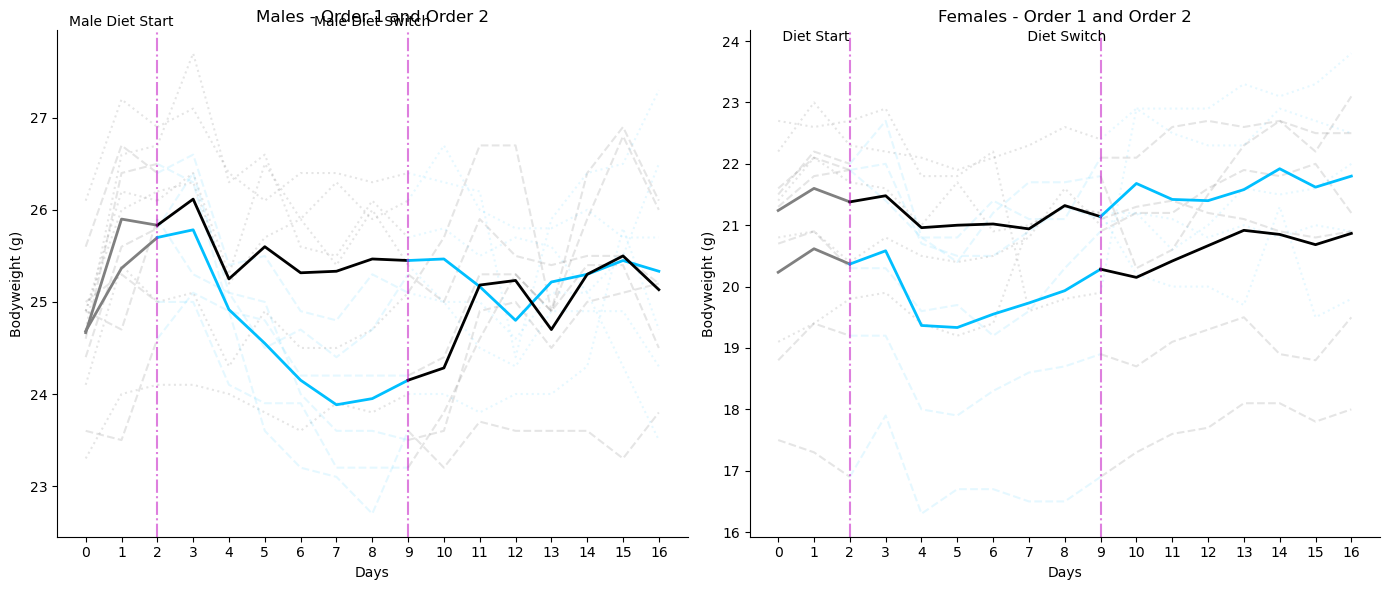

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/Bodyweight/BODYWEIGHT.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for each sex and order
def get_order_data(order, sex):
    data = meals_per_day_data[(meals_per_day_data["Order"] == order) & (meals_per_day_data["Sex"] == sex)]
    if order == 1:
        return data[grain_cols + nr_cols + pr_cols].values  # Order 1: Grain -> NR -> PR
    else:
        return data[grain_cols + pr_cols + nr_cols].values  # Order 2: Grain -> PR -> NR

male_order_1 = get_order_data(1, "M")
male_order_2 = get_order_data(2, "M")
female_order_1 = get_order_data(1, "F")
female_order_2 = get_order_data(2, "F")

# Function to plot data for a single sex on a specified axis
def plot_by_sex_in_subplot(ax, data_order1, data_order2, color_order1_phase1, color_order1_phase2, color_order2_phase1, color_order2_phase2, title, line_text_start, line_text_switch, text_y_position_start, text_y_position_switch):
    # Plot each individual trace for Order 1 (20% Casein -> 5% Casein)
    for trace in data_order1:
        ax.plot(range(3), trace[:3], color="black", linestyle='dotted', alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order1_phase1, linestyle='dotted', alpha=0.1)  # NR phase (20% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order1_phase2, linestyle='dotted', alpha=0.1)  # PR phase (5% Casein)

    # Plot each individual trace for Order 2 (5% Casein -> 20% Casein)
    for trace in data_order2:
        ax.plot(range(3), trace[:3], color="black", linestyle='dashed', alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order2_phase1, linestyle='dashed', alpha=0.1)  # PR phase (5% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order2_phase2, linestyle='dashed', alpha=0.1)  # NR phase (20% Casein)

    # Plot the combined mean lines for Order 1 and Order 2
    mean_trace_order1 = np.mean(data_order1, axis=0)
    mean_trace_order2 = np.mean(data_order2, axis=0)
    
    # Order 1 mean lines (20% Casein -> 5% Casein)
    ax.plot(range(3), mean_trace_order1[:3], color="grey", linewidth=2)  # Grain phase (grey)
    ax.plot(range(2, 10), mean_trace_order1[2:10], color=color_order1_phase1, linewidth=2, label="Order 1")  # NR phase
    ax.plot(range(9, 17), mean_trace_order1[9:], color=color_order1_phase2, linewidth=2)  # PR phase
    
    # Order 2 mean lines (5% Casein -> 20% Casein)
    ax.plot(range(3), mean_trace_order2[:3], color="grey", linewidth=2)
    ax.plot(range(2, 10), mean_trace_order2[2:10], color=color_order2_phase1, linewidth=2, label="Order 2")  # PR phase
    ax.plot(range(9, 17), mean_trace_order2[9:], color=color_order2_phase2, linewidth=2)  # NR phase

    # Add vertical lines for diet phase transitions, with customizable text and positions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, text_y_position_start, line_text_start, ha='center')
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, text_y_position_switch, line_text_switch, ha='center')

    # Formatting
    ax.set_ylabel("Bodyweight (g)")
    ax.set_xlabel("Days")
    ax.set_xticks(range(17))
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

# Creating a single figure with subplots for male and female
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot for males on ax1 with specific label positions and texts
plot_by_sex_in_subplot(
    ax1, male_order_1, male_order_2, "black", "deepskyblue", "deepskyblue", "black",
    "Males - Order 1 and Order 2", line_text_start="Male Diet Start", line_text_switch="Male Diet Switch",
    text_y_position_start=28, text_y_position_switch=28
)

# Plot for females on ax2 with specific label positions and texts
plot_by_sex_in_subplot(
    ax2, female_order_1, female_order_2, "black", "deepskyblue", "deepskyblue", "black",
    "Females - Order 1 and Order 2", line_text_start=" Diet Start", line_text_switch=" Diet Switch",
    text_y_position_start=24, text_y_position_switch=24
)

# Adjust layout and display
plt.tight_layout()
plt.show()


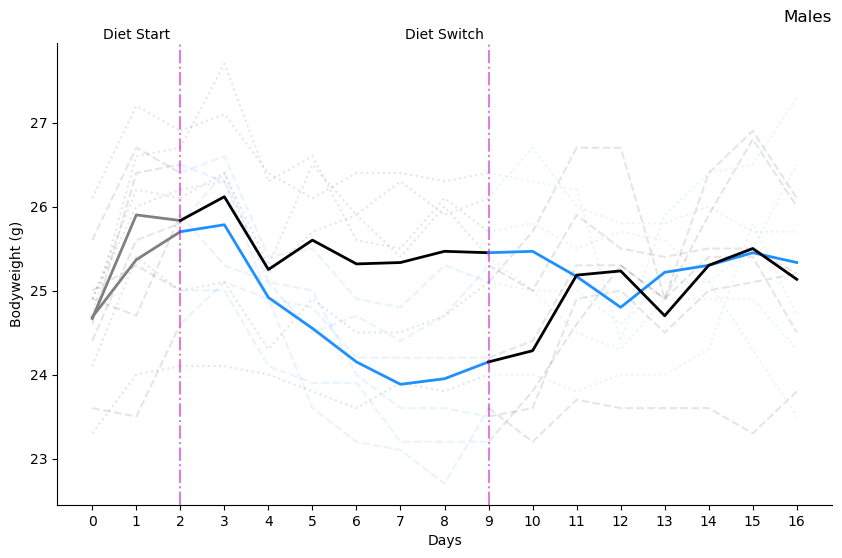

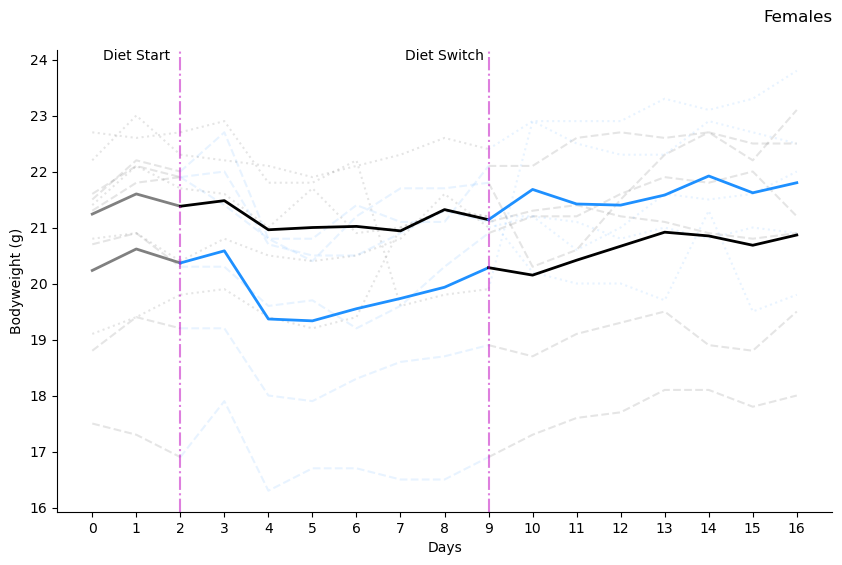

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/Bodyweight/BODYWEIGHT.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for each sex and order
def get_order_data(order, sex):
    data = meals_per_day_data[(meals_per_day_data["Order"] == order) & (meals_per_day_data["Sex"] == sex)]
    if order == 1:
        return data[grain_cols + nr_cols + pr_cols].values  # Order 1: Grain -> NR -> PR
    else:
        return data[grain_cols + pr_cols + nr_cols].values  # Order 2: Grain -> PR -> NR

male_order_1 = get_order_data(1, "M")
male_order_2 = get_order_data(2, "M")
female_order_1 = get_order_data(1, "F")
female_order_2 = get_order_data(2, "F")

def plot_by_sex(data_order1, data_order2, color_order1_phase1, color_order1_phase2, color_order2_phase1, color_order2_phase2, title, line_text_start, line_text_switch, text_y_position_start, text_y_position_switch, title_loc="center", title_pad=10):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each individual trace for Order 1 (20% Casein -> 5% Casein)
    for trace in data_order1:
        ax.plot(range(3), trace[:3], color="black", linestyle='dotted', alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order1_phase1, linestyle='dotted', alpha=0.1)  # NR phase (20% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order1_phase2, linestyle='dotted', alpha=0.1)  # PR phase (5% Casein)

    # Plot each individual trace for Order 2 (5% Casein -> 20% Casein)
    for trace in data_order2:
        ax.plot(range(3), trace[:3], color="black", linestyle='dashed', alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order2_phase1, linestyle='dashed', alpha=0.1)  # PR phase (5% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order2_phase2, linestyle='dashed', alpha=0.1)  # NR phase (20% Casein)

    # Plot the combined mean lines for Order 1 and Order 2
    mean_trace_order1 = np.mean(data_order1, axis=0)
    mean_trace_order2 = np.mean(data_order2, axis=0)
    
    # Order 1 mean lines (20% Casein -> 5% Casein)
    ax.plot(range(3), mean_trace_order1[:3], color="grey", linewidth=2)  # Grain phase (grey)
    ax.plot(range(2, 10), mean_trace_order1[2:10], color=color_order1_phase1, linewidth=2, label="Order 1")  # NR phase
    ax.plot(range(9, 17), mean_trace_order1[9:], color=color_order1_phase2, linewidth=2)  # PR phase
    
    # Order 2 mean lines (5% Casein -> 20% Casein)
    ax.plot(range(3), mean_trace_order2[:3], color="grey", linewidth=2)
    ax.plot(range(2, 10), mean_trace_order2[2:10], color=color_order2_phase1, linewidth=2, label="Order 2")  # PR phase
    ax.plot(range(9, 17), mean_trace_order2[9:], color=color_order2_phase2, linewidth=2)  # NR phase

    # Add vertical lines for diet phase transitions, with customizable text and positions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, text_y_position_start, line_text_start, ha='center')
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, text_y_position_switch, line_text_switch, ha='center')

    # Formatting
    ax.set_ylabel("Bodyweight (g)")
    ax.set_xlabel("Days")
    ax.set_xticks(range(17))
    ax.set_title(title, loc=title_loc, pad=title_pad)  # Adjust title position
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    plt.show()

# Plot for males with specific label positions and texts
plot_by_sex(
    male_order_1, male_order_2, "black", "dodgerblue", "dodgerblue", "black",
    "Males", line_text_start="Diet Start", line_text_switch="Diet Switch",
    text_y_position_start=28, text_y_position_switch=28, title_loc="right", title_pad=15
)

# Plot for females with specific label positions and texts
plot_by_sex(
    female_order_1, female_order_2, "black", "dodgerblue", "dodgerblue", "black",
    "Females", line_text_start="Diet Start", line_text_switch="Diet Switch",
    text_y_position_start=24, text_y_position_switch=24, title_loc="right", title_pad=20
)



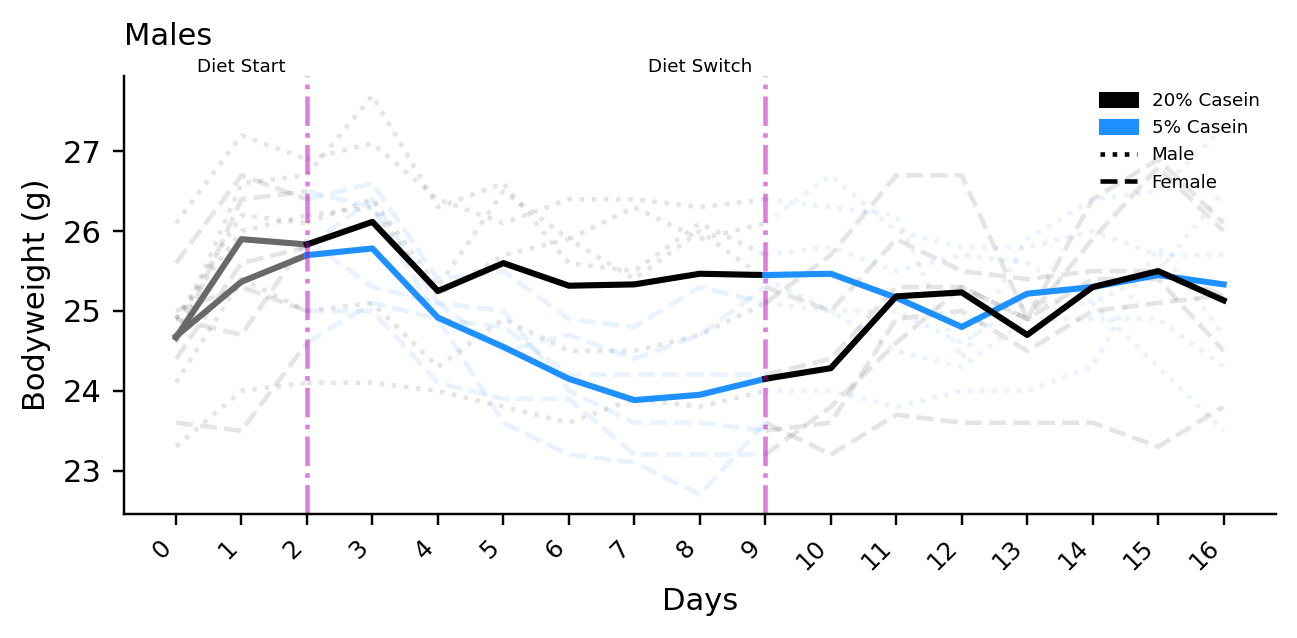

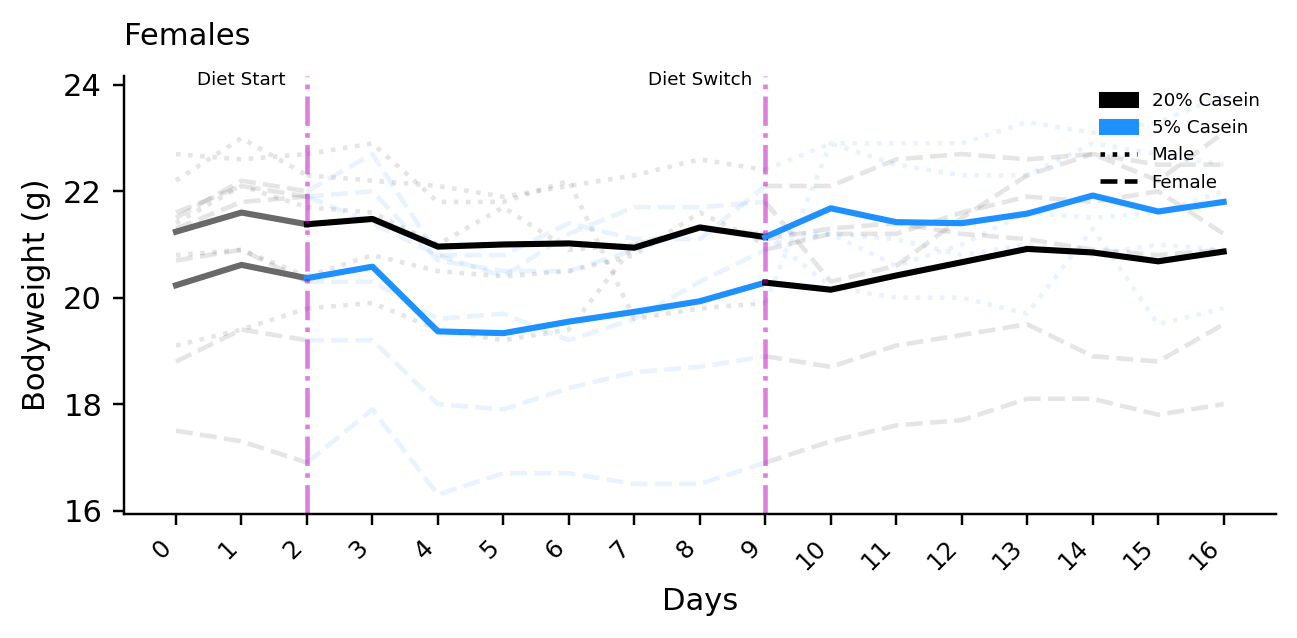

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/Bodyweight/BODYWEIGHT.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for each sex and order
def get_order_data(order, sex):
    data = meals_per_day_data[(meals_per_day_data["Order"] == order) & (meals_per_day_data["Sex"] == sex)]
    if order == 1:
        return data[grain_cols + nr_cols + pr_cols].values  # Order 1: Grain -> NR -> PR
    else:
        return data[grain_cols + pr_cols + nr_cols].values  # Order 2: Grain -> PR -> NR

male_order_1 = get_order_data(1, "M")
male_order_2 = get_order_data(2, "M")
female_order_1 = get_order_data(1, "F")
female_order_2 = get_order_data(2, "F")

def plot_by_sex(data_order1, data_order2, color_order1_phase1, color_order1_phase2, color_order2_phase1, color_order2_phase2, title, line_text_start, line_text_switch, text_y_position_start, text_y_position_switch, title_loc="center", title_pad=10):
    fig, ax = plt.subplots(figsize=(6, 3), dpi=220)

    # Plot each individual trace for Order 1 (20% Casein -> 5% Casein)
    for trace in data_order1:
        ax.plot(range(3), trace[:3], color="black", linestyle='dotted', alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order1_phase1, linestyle='dotted', alpha=0.1)  # NR phase (20% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order1_phase2, linestyle='dotted', alpha=0.1)  # PR phase (5% Casein)

    # Plot each individual trace for Order 2 (5% Casein -> 20% Casein)
    for trace in data_order2:
        ax.plot(range(3), trace[:3], color="black", linestyle='dashed', alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order2_phase1, linestyle='dashed', alpha=0.1)  # PR phase (5% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order2_phase2, linestyle='dashed', alpha=0.1)  # NR phase (20% Casein)

    # Plot the combined mean lines for Order 1 and Order 2
    mean_trace_order1 = np.nanmean(data_order1, axis=0)
    mean_trace_order2 = np.nanmean(data_order2, axis=0)
    
    # Order 1 mean lines (20% Casein -> 5% Casein)
    ax.plot(range(3), mean_trace_order1[:3], color="dimgray", linewidth=2)  # Grain phase (grey)
    ax.plot(range(2, 10), mean_trace_order1[2:10], color=color_order1_phase1, linewidth=2, label="Order 1")  # NR phase
    ax.plot(range(9, 17), mean_trace_order1[9:], color=color_order1_phase2, linewidth=2)  # PR phase
    
    # Order 2 mean lines (5% Casein -> 20% Casein)
    ax.plot(range(3), mean_trace_order2[:3], color="dimgray", linewidth=2)  # Grain phase (grey)
    ax.plot(range(2, 10), mean_trace_order2[2:10], color=color_order2_phase1, linewidth=2, label="Order 2")  # PR phase
    ax.plot(range(9, 17), mean_trace_order2[9:], color=color_order2_phase2, linewidth=2)  # NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, text_y_position_start, line_text_start, ha='center', fontsize=6)
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, text_y_position_switch, line_text_switch, ha='center', fontsize=6)

    # Formatting
    ax.set_ylabel("Bodyweight (g)", fontsize=10)
    ax.set_xlabel("Days", fontsize=10)
    ax.set_xticks(range(17))
    ax.set_xticklabels(range(17), fontsize=8, rotation=45, ha="right")
    ax.set_title(title, loc="left", pad=title_pad, fontsize=10)  # Adjust title position to left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # Add legend for the phases and line styles
    NR_patch = mpatches.Patch(color="black", label="20% Casein")
    PR_patch = mpatches.Patch(color="dodgerblue", label="5% Casein")
    ax.set_title(title, loc="left", pad=title_pad, fontsize=10)  # Adjust title position to left
    male_line = mlines.Line2D([], [], color="black", linestyle='dotted', label='Male')
    female_line = mlines.Line2D([], [], color="black", linestyle='dashed', label='Female')
    ax.legend(handles=[NR_patch, PR_patch, male_line, female_line], loc="upper right", fontsize=6, frameon=False)

    plt.tight_layout()
    plt.show()

# Plot for males
plot_by_sex(
    male_order_1, male_order_2, "black", "dodgerblue", "dodgerblue", "black",
    "Males", line_text_start="Diet Start", line_text_switch="Diet Switch",
    text_y_position_start=28, text_y_position_switch=28, title_loc="center", title_pad=10
)

# Plot for females
plot_by_sex(
    female_order_1, female_order_2, "black", "dodgerblue", "dodgerblue", "black",
    "Females", line_text_start="Diet Start", line_text_switch="Diet Switch",
    text_y_position_start=24, text_y_position_switch=24, title_loc="center", title_pad=10
)


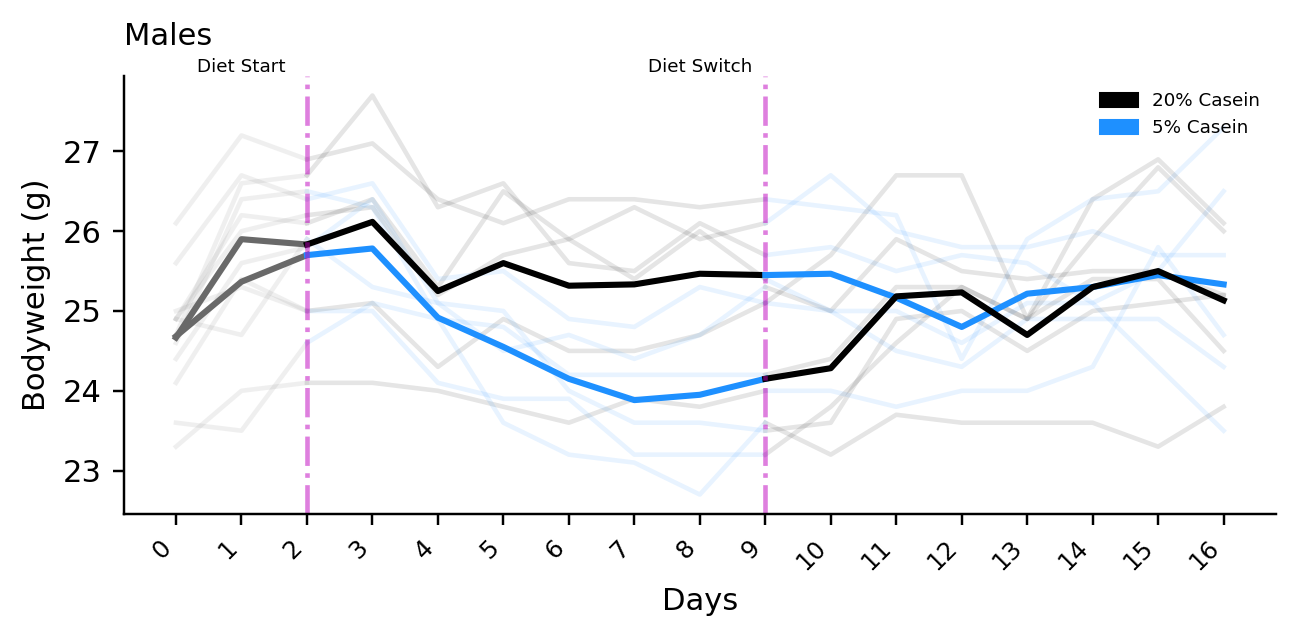

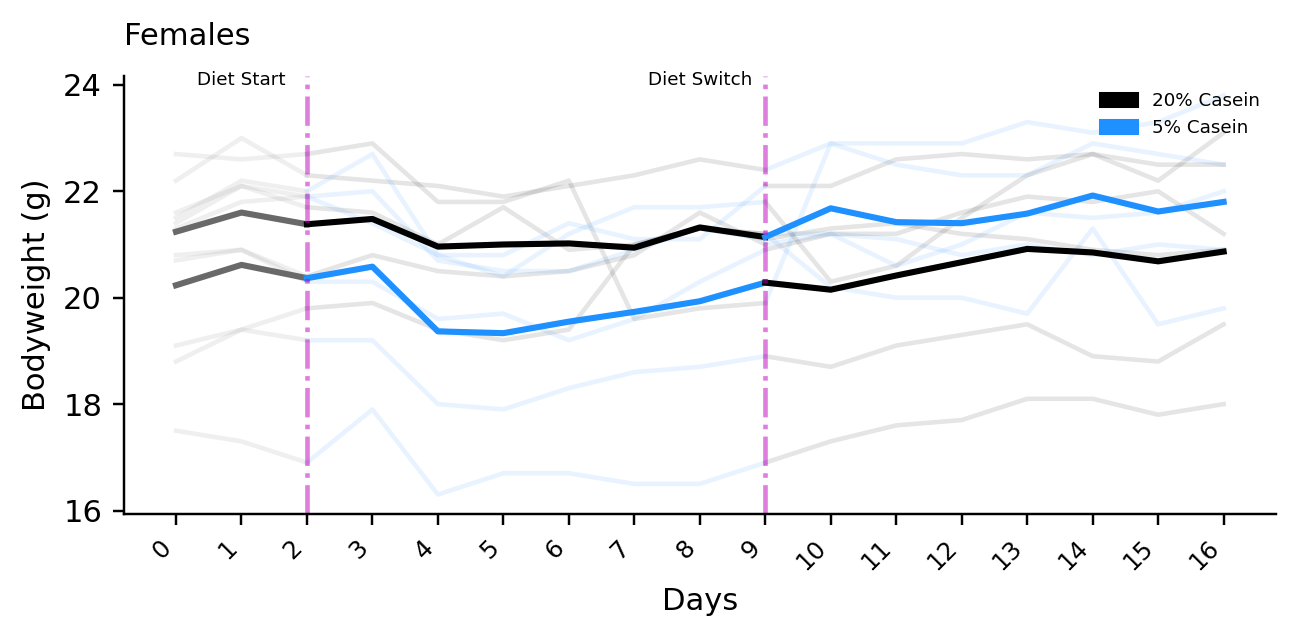

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/Bodyweight/BODYWEIGHT.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for each sex and order
def get_order_data(order, sex):
    data = meals_per_day_data[(meals_per_day_data["Order"] == order) & (meals_per_day_data["Sex"] == sex)]
    if order == 1:
        return data[grain_cols + nr_cols + pr_cols].values  # Order 1: Grain -> NR -> PR
    else:
        return data[grain_cols + pr_cols + nr_cols].values  # Order 2: Grain -> PR -> NR

male_order_1 = get_order_data(1, "M")
male_order_2 = get_order_data(2, "M")
female_order_1 = get_order_data(1, "F")
female_order_2 = get_order_data(2, "F")

def plot_by_sex(data_order1, data_order2, color_order1_phase1, color_order1_phase2, color_order2_phase1, color_order2_phase2, title, line_text_start, line_text_switch, text_y_position_start, text_y_position_switch, title_loc="center", title_pad=10):
    fig, ax = plt.subplots(figsize=(6, 3), dpi=220)

    # Plot each individual trace for Order 1 with the same colour as the average line
    for trace in data_order1:
        ax.plot(range(3), trace[:3], color="dimgray", alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order1_phase1, alpha=0.1)  # NR phase (20% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order1_phase2, alpha=0.1)  # PR phase (5% Casein)

    # Plot each individual trace for Order 2 with the same colour as the average line
    for trace in data_order2:
        ax.plot(range(3), trace[:3], color="dimgray", alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order2_phase1, alpha=0.1)  # PR phase (5% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order2_phase2, alpha=0.1)  # NR phase (20% Casein)

    # Plot the combined mean lines for Order 1 and Order 2
    mean_trace_order1 = np.nanmean(data_order1, axis=0)
    mean_trace_order2 = np.nanmean(data_order2, axis=0)
    
    # Order 1 mean lines
    ax.plot(range(3), mean_trace_order1[:3], color="dimgray", linewidth=2)  # Grain phase (grey)
    ax.plot(range(2, 10), mean_trace_order1[2:10], color=color_order1_phase1, linewidth=2, label="Order 1")  # NR phase
    ax.plot(range(9, 17), mean_trace_order1[9:], color=color_order1_phase2, linewidth=2)  # PR phase
    
    # Order 2 mean lines
    ax.plot(range(3), mean_trace_order2[:3], color="dimgray", linewidth=2)  # Grain phase (grey)
    ax.plot(range(2, 10), mean_trace_order2[2:10], color=color_order2_phase1, linewidth=2, label="Order 2")  # PR phase
    ax.plot(range(9, 17), mean_trace_order2[9:], color=color_order2_phase2, linewidth=2)  # NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, text_y_position_start, line_text_start, ha='center', fontsize=6)
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, text_y_position_switch, line_text_switch, ha='center', fontsize=6)

    # Formatting
    ax.set_ylabel("Bodyweight (g)", fontsize=10)
    ax.set_xlabel("Days", fontsize=10)
    ax.set_xticks(range(17))
    ax.set_xticklabels(range(17), fontsize=8, rotation=45, ha="right")
    ax.set_title(title, loc="left", pad=title_pad, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # Add legend for the phases
    NR_patch = mpatches.Patch(color="black", label="20% Casein")
    PR_patch = mpatches.Patch(color="dodgerblue", label="5% Casein")
    ax.legend(handles=[NR_patch, PR_patch], loc="upper right", fontsize=6, frameon=False)

    plt.tight_layout()
    plt.show()

# Plot for males
plot_by_sex(
    male_order_1, male_order_2, "black", "dodgerblue", "dodgerblue", "black",
    "Males", line_text_start="Diet Start", line_text_switch="Diet Switch",
    text_y_position_start=28, text_y_position_switch=28, title_loc="center", title_pad=10
)

# Plot for females
plot_by_sex(
    female_order_1, female_order_2, "black", "dodgerblue", "dodgerblue", "black",
    "Females", line_text_start="Diet Start", line_text_switch="Diet Switch",
    text_y_position_start=24, text_y_position_switch=24, title_loc="center", title_pad=10
)


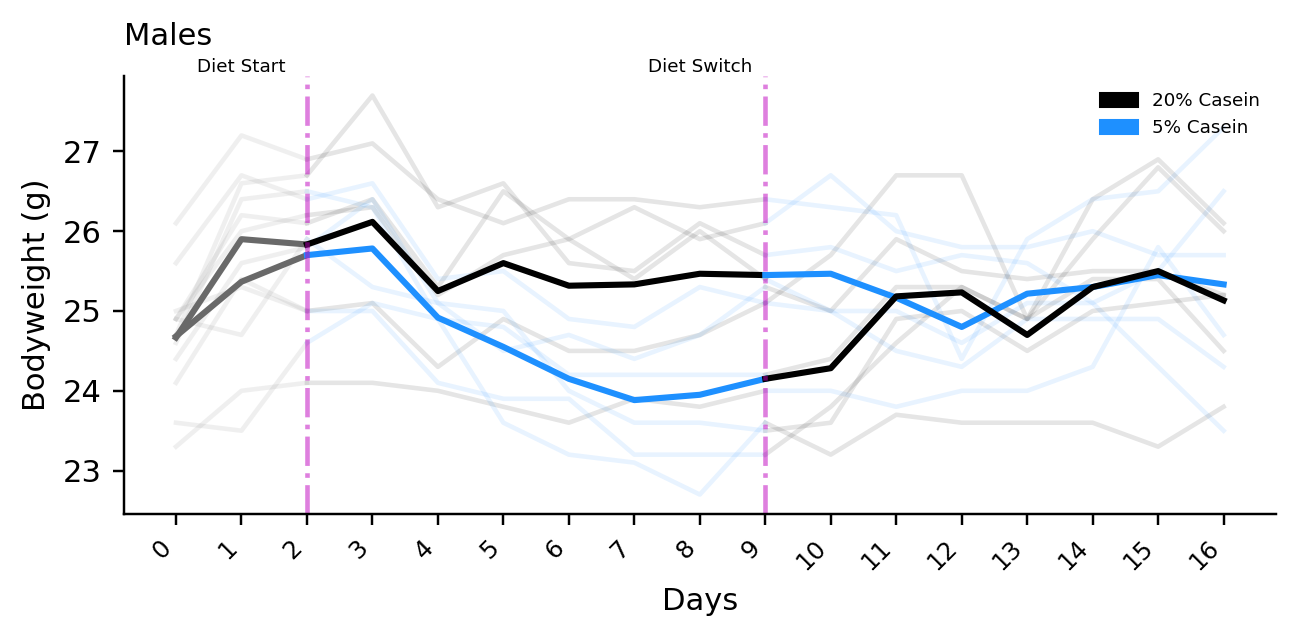

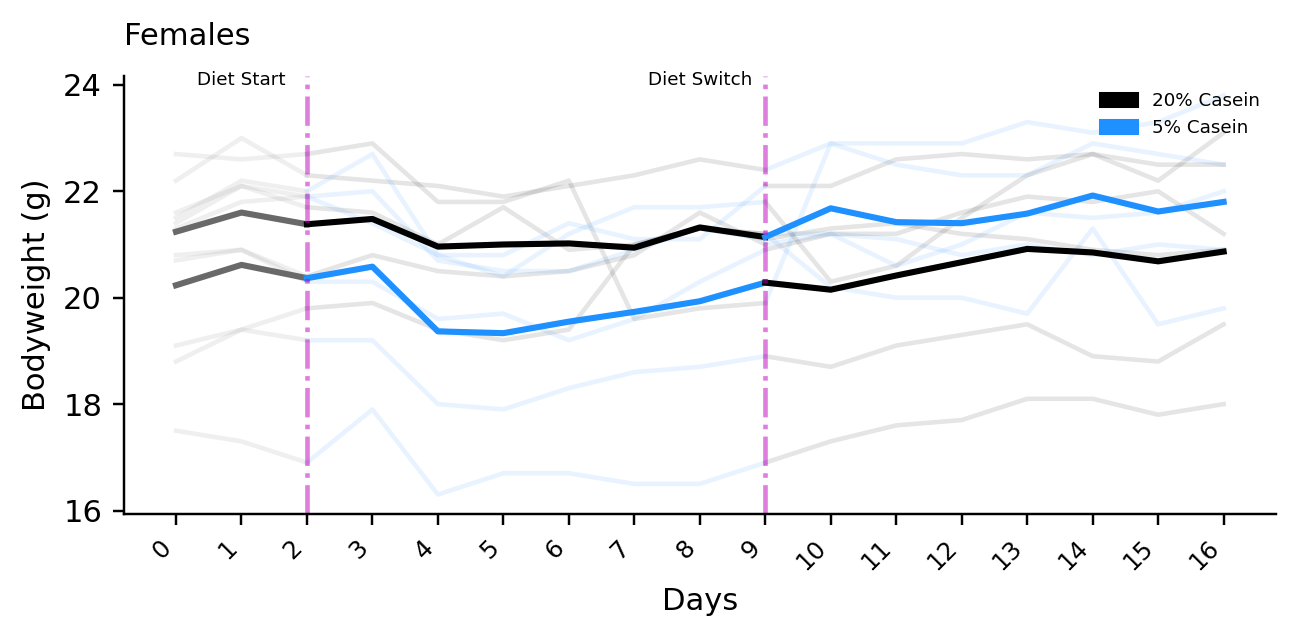

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/Bodyweight/BODYWEIGHT.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for each sex and order
def get_order_data(order, sex):
    data = meals_per_day_data[(meals_per_day_data["Order"] == order) & (meals_per_day_data["Sex"] == sex)]
    if order == 1:
        return data[grain_cols + nr_cols + pr_cols].values  # Order 1: Grain -> NR -> PR
    else:
        return data[grain_cols + pr_cols + nr_cols].values  # Order 2: Grain -> PR -> NR

male_order_1 = get_order_data(1, "M")
male_order_2 = get_order_data(2, "M")
female_order_1 = get_order_data(1, "F")
female_order_2 = get_order_data(2, "F")

def plot_by_sex(data_order1, data_order2, color_order1_phase1, color_order1_phase2, color_order2_phase1, color_order2_phase2, title, line_text_start, line_text_switch, text_y_position_start, text_y_position_switch, save_path, title_loc="center", title_pad=10):
    fig, ax = plt.subplots(figsize=(6, 3), dpi=220)

    # Plot each individual trace for Order 1 with the same colour as the average line
    for trace in data_order1:
        ax.plot(range(3), trace[:3], color="dimgray", alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order1_phase1, alpha=0.1)  # NR phase (20% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order1_phase2, alpha=0.1)  # PR phase (5% Casein)

    # Plot each individual trace for Order 2 with the same colour as the average line
    for trace in data_order2:
        ax.plot(range(3), trace[:3], color="dimgray", alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order2_phase1, alpha=0.1)  # PR phase (5% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order2_phase2, alpha=0.1)  # NR phase (20% Casein)

    # Plot the combined mean lines for Order 1 and Order 2
    mean_trace_order1 = np.nanmean(data_order1, axis=0)
    mean_trace_order2 = np.nanmean(data_order2, axis=0)
    
    # Order 1 mean lines
    ax.plot(range(3), mean_trace_order1[:3], color="dimgray", linewidth=2)  # Grain phase (grey)
    ax.plot(range(2, 10), mean_trace_order1[2:10], color=color_order1_phase1, linewidth=2, label="Order 1")  # NR phase
    ax.plot(range(9, 17), mean_trace_order1[9:], color=color_order1_phase2, linewidth=2)  # PR phase
    
    # Order 2 mean lines
    ax.plot(range(3), mean_trace_order2[:3], color="dimgray", linewidth=2)  # Grain phase (grey)
    ax.plot(range(2, 10), mean_trace_order2[2:10], color=color_order2_phase1, linewidth=2, label="Order 2")  # PR phase
    ax.plot(range(9, 17), mean_trace_order2[9:], color=color_order2_phase2, linewidth=2)  # NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="m", alpha=0.5)
    ax.text(1, text_y_position_start, line_text_start, ha='center', fontsize=6)
    ax.axvline(9, linestyle="-.", color="m", alpha=0.5)
    ax.text(8, text_y_position_switch, line_text_switch, ha='center', fontsize=6)

    # Formatting
    ax.set_ylabel("Bodyweight (g)", fontsize=10)
    ax.set_xlabel("Days", fontsize=10)
    ax.set_xticks(range(17))
    ax.set_xticklabels(range(17), fontsize=8, rotation=45, ha="right")
    ax.set_title(title, loc="left", pad=title_pad, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # Add legend for the phases
    NR_patch = mpatches.Patch(color="black", label="20% Casein")
    PR_patch = mpatches.Patch(color="dodgerblue", label="5% Casein")
    ax.legend(handles=[NR_patch, PR_patch], loc="upper right", fontsize=6, frameon=False)

    plt.tight_layout()
    fig.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

# Plot for males
plot_by_sex(
    male_order_1, male_order_2, "black", "dodgerblue", "dodgerblue", "black",
    "Males", line_text_start="Diet Start", line_text_switch="Diet Switch",
    text_y_position_start=28, text_y_position_switch=28,
    save_path="../plots/NEW_MEAL_PLOTS/Bodyweight_Males.png", title_loc="center", title_pad=10
)

# Plot for females
plot_by_sex(
    female_order_1, female_order_2, "black", "dodgerblue", "dodgerblue", "black",
    "Females", line_text_start="Diet Start", line_text_switch="Diet Switch",
    text_y_position_start=24, text_y_position_switch=24,
    save_path="../plots/NEW_MEAL_PLOTS/Bodyweight_Females.png", title_loc="center", title_pad=10
)


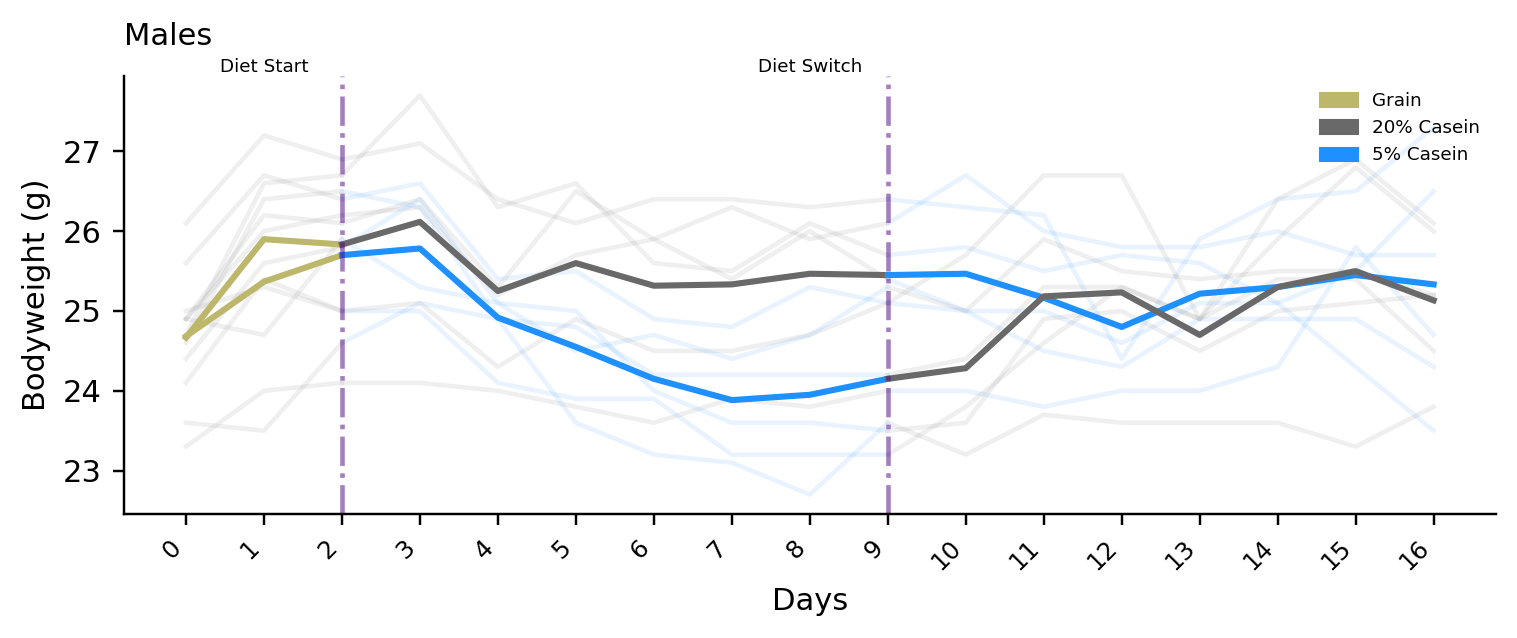

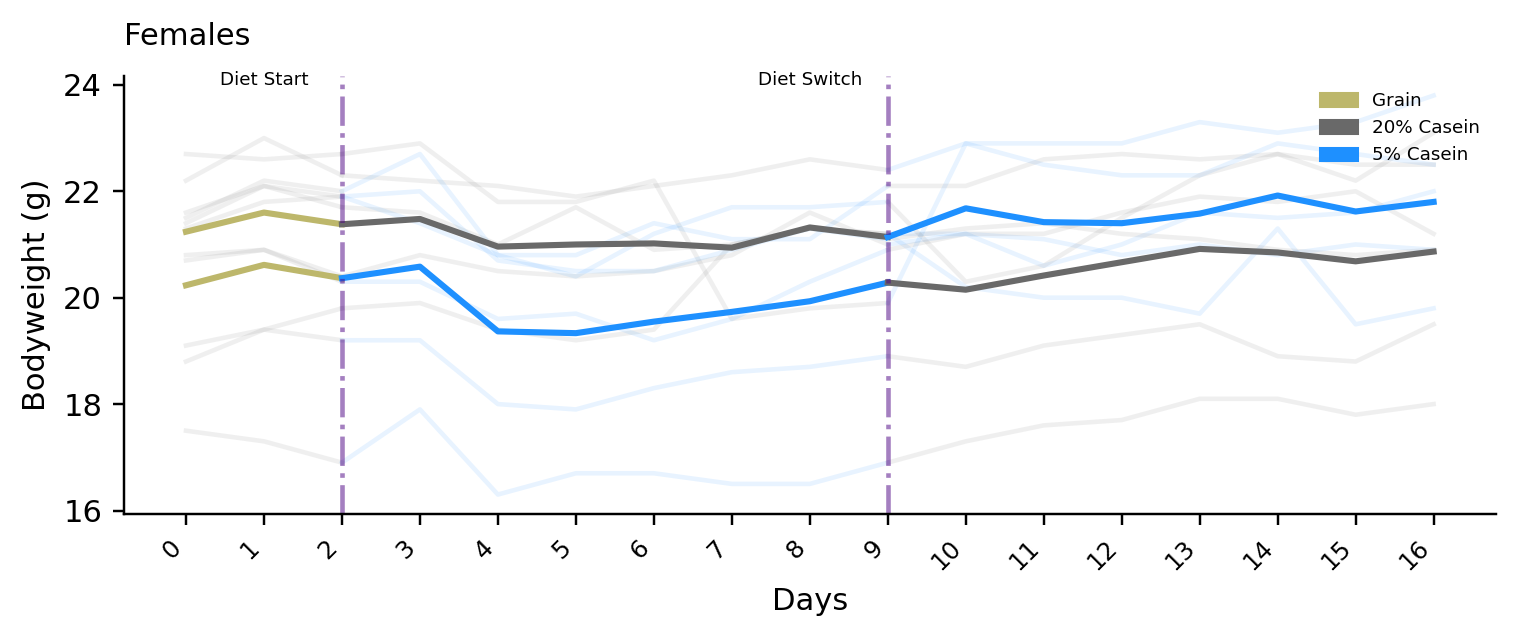

In [65]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches

# Load the data file
file_path = '../results/FIVE/LINE_PLOTS/Bodyweight/BODYWEIGHT.csv'
meals_per_day_data = pd.read_csv(file_path)

# Define the correct sequences for each order
grain_cols = ["G0", "G1", "G2"]
nr_cols = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Arrange data for each sex and order
def get_order_data(order, sex):
    data = meals_per_day_data[(meals_per_day_data["Order"] == order) & (meals_per_day_data["Sex"] == sex)]
    if order == 1:
        return data[grain_cols + nr_cols + pr_cols].values  # Order 1: Grain -> NR -> PR
    else:
        return data[grain_cols + pr_cols + nr_cols].values  # Order 2: Grain -> PR -> NR

male_order_1 = get_order_data(1, "M")
male_order_2 = get_order_data(2, "M")
female_order_1 = get_order_data(1, "F")
female_order_2 = get_order_data(2, "F")






def plot_by_sex(data_order1, data_order2, color_order1_phase1, color_order1_phase2, color_order2_phase1, color_order2_phase2, title, line_text_start, line_text_switch, text_y_position_start, text_y_position_switch, save_path, title_loc="center", title_pad=10):
    fig, ax = plt.subplots(figsize=(7, 3), dpi=220)

    # Plot each individual trace for Order 1 with the same colour as the average line
    for trace in data_order1:
        ax.plot(range(3), trace[:3], color="dimgray", alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order1_phase1, alpha=0.1)  # NR phase (20% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order1_phase2, alpha=0.1)  # PR phase (5% Casein)

    # Plot each individual trace for Order 2 with the same colour as the average line
    for trace in data_order2:
        ax.plot(range(3), trace[:3], color="dimgray", alpha=0.1)  # Grain phase
        ax.plot(range(2, 10), trace[2:10], color=color_order2_phase1, alpha=0.1)  # PR phase (5% Casein)
        ax.plot(range(9, 17), trace[9:], color=color_order2_phase2, alpha=0.1)  # NR phase (20% Casein)

    # Plot the combined mean lines for Order 1 and Order 2
    mean_trace_order1 = np.nanmean(data_order1, axis=0)
    mean_trace_order2 = np.nanmean(data_order2, axis=0)
    
    # Order 1 mean lines
    ax.plot(range(3), mean_trace_order1[:3], color="darkkhaki", linewidth=2)  # Grain phase (green)
    ax.plot(range(2, 10), mean_trace_order1[2:10], color=color_order1_phase1, linewidth=2, label="Order 1")  # NR phase
    ax.plot(range(9, 17), mean_trace_order1[9:], color=color_order1_phase2, linewidth=2)  # PR phase
    
    # Order 2 mean lines
    ax.plot(range(3), mean_trace_order2[:3], color="darkkhaki", linewidth=2)  # Grain phase (green)
    ax.plot(range(2, 10), mean_trace_order2[2:10], color=color_order2_phase1, linewidth=2, label="Order 2")  # PR phase
    ax.plot(range(9, 17), mean_trace_order2[9:], color=color_order2_phase2, linewidth=2)  # NR phase

    # Add vertical lines for diet phase transitions
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.5)
    ax.text(1, text_y_position_start, line_text_start, ha='center', fontsize=6)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.5)
    ax.text(8, text_y_position_switch, line_text_switch, ha='center', fontsize=6)

    # Formatting
    ax.set_ylabel("Bodyweight (g)", fontsize=10)
    ax.set_xlabel("Days", fontsize=10)
    ax.set_xticks(range(17))
    ax.set_xticklabels(range(17), fontsize=8, rotation=45, ha="right")
    ax.set_title(title, loc="left", pad=title_pad, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # Add legend for the phases
    Grain_patch = mpatches.Patch(color="darkkhaki", label="Grain")
    NR_patch = mpatches.Patch(color="dimgray", label="20% Casein")
    PR_patch = mpatches.Patch(color="dodgerblue", label="5% Casein")
    ax.legend(handles=[Grain_patch, NR_patch, PR_patch], loc="upper right", fontsize=6, frameon=False)

    plt.tight_layout()
    fig.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()






# Plot for males
plot_by_sex(
    male_order_1, male_order_2, "dimgray", "dodgerblue", "dodgerblue", "dimgray",
    "Males", line_text_start="Diet Start", line_text_switch="Diet Switch",
    text_y_position_start=28, text_y_position_switch=28,
    save_path="../plots/NEW_MEAL_PLOTS/Bodyweight_Males.png", title_loc="center", title_pad=10
)

# Plot for females
plot_by_sex(
    female_order_1, female_order_2, "dimgray", "dodgerblue", "dodgerblue", "dimgray",
    "Females", line_text_start="Diet Start", line_text_switch="Diet Switch",
    text_y_position_start=24, text_y_position_switch=24,
    save_path="../plots/NEW_MEAL_PLOTS/Bodyweight_Females.png", title_loc="center", title_pad=10
)
